# Eventos de violencia organizada (UCDP GED)

El dataset UCDP GED documenta eventos de violencia organizada en el mundo, incluyendo detalles temporales, geográficos y del tipo de conflicto. Este proyecto busca explorar patrones de violencia, tendencias temporales, distribución geográfica y posibles indicadores predictivos.

El mismo puede descargarse desde https://ucdp.uu.se/downloads/index.html#ged_global

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder

# ── Estilo global: minimalista ──────────────────────────────────
plt.rcParams.update({
    'figure.facecolor' : 'white',
    'axes.facecolor'   : 'white',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : False,
    'font.size'        : 11,
    'axes.titlesize'   : 12,
    'axes.titleweight' : 'bold',
    'axes.labelsize'   : 10,
})


In [2]:
data = pd.read_csv("/Users/maximilianocencic/Documents/maestria/AdD-Grupo-8-UCDP-GED/dataset/GEDEvent_v25_1.csv", low_memory=False)
data.head(5)

,id,relid,year,active_year,code_status,type_of_violence,conflict_dset_id,conflict_new_id,conflict_name,dyad_dset_id,...,date_end,deaths_a,deaths_b,deaths_civilians,deaths_unknown,best,high,low,gwnoa,gwnob
0,244657,IRQ-2017-1-524-322,2017,True,Clear,1,259,259,Iraq: Government,524,...,2017-07-31 00:00:00.000,0,4,0,2,6,6,6,645,NaN
1,412700,IRQ-2021-1-524-145,2021,True,Clear,1,259,259,Iraq: Government,524,...,2021-08-26 00:00:00.000,13,1,141,28,183,184,171,645,NaN
2,413023,IRQ-2021-1-524-143,2021,True,Clear,1,259,259,Iraq: Government,524,...,2021-08-28 00:00:00.000,0,2,0,0,2,3,0,645,NaN
3,412909,IRQ-2021-1-524-144,2021,True,Clear,1,259,259,Iraq: Government,524,...,2021-08-29 00:00:00.000,0,0,10,0,10,10,9,645,NaN
4,132140,AFG-1989-1-411-2,1989,True,Clear,1,333,333,Afghanistan: Government,724,...,1989-01-13 00:00:00.000,6,0,0,0,6,6,6,700,NaN


## Descripción general del dataset

In [3]:
# ─────────────────────────────────────────────
# RESUMEN GENERAL — UCDP GED
# ─────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

num_rows, num_cols = data.shape

# Rango temporal
year_col = next((c for c in data.columns if 'year' in c.lower()), None)
year_range = f"{int(data[year_col].min())} - {int(data[year_col].max())}" if year_col else "No disponible"

# ── Clasificación semántica de columnas ──────────────────────────────────
# IDs y códigos internos (no analíticos)
ID_COLS   = ['id', 'relid', 'conflict_dset_id', 'conflict_new_id',
             'dyad_dset_id', 'dyad_new_id', 'side_a_dset_id', 'side_a_new_id',
             'side_b_dset_id', 'side_b_new_id', 'priogrid_gid', 'country_id',
             'code_status', 'gwnoa', 'gwnob']

# Fechas
DATE_COLS = ['date_start', 'date_end', 'source_date']

# Texto libre / fuente (no analítico)
TEXT_COLS = ['source_article', 'source_office', 'source_headline',
             'source_original', 'where_coordinates', 'where_description',
             'adm_1', 'adm_2', 'geom_wkt']

# Columnas categóricas analíticas (útiles para agrupar/filtrar)
CATEGORICAL_COLS = ['conflict_name', 'dyad_name', 'side_a', 'side_b',
                    'adm1', 'adm2', 'country', 'region', 'type_of_violence', 'where_prec',
                    'event_clarity', 'date_prec', 'number_of_sources']

# Columnas numéricas analíticas
NUMERIC_COLS = ['year', 'latitude', 'longitude',
                'deaths_a', 'deaths_b', 'deaths_civilians', 'deaths_unknown',
                'best', 'high', 'low']

# Filtrar solo las que existen en el dataset cargado
id_cols          = [c for c in ID_COLS          if c in data.columns]
date_cols        = [c for c in DATE_COLS        if c in data.columns]
text_cols        = [c for c in TEXT_COLS        if c in data.columns]
categorical_vars = [c for c in CATEGORICAL_COLS if c in data.columns]
numeric_vars     = [c for c in NUMERIC_COLS     if c in data.columns]

# Columnas con alto porcentaje de nulos (> 40%)
null_pct       = data.isnull().mean().sort_values(ascending=False)
high_null_cols = null_pct[null_pct > 0.4]

print("\n══════════════════════════════════════════")
print("  RESUMEN DEL DATASET — UCDP GED")
print("══════════════════════════════════════════")
print(f"  Filas              : {num_rows:,}")
print(f"  Columnas           : {num_cols}")
print(f"  Columnas tipo ID   : {len(id_cols)}")
print(f"  Columnas de fecha  : {len(date_cols)}")
print(f"  Columnas texto/src : {len(text_cols)}")
print(f"  Rango de años      : {year_range}")
print()
print("── Variables categóricas ────")
for v in categorical_vars:
    n_unique = data[v].nunique()
    print(f"   • {v:<30} ({n_unique:,} valores únicos)")
print()
print("── Variables numéricas ──────")
for v in numeric_vars:
    print(f"   • {v}")
print()
print("── Features con > 40% nulos ──────────────")
if high_null_cols.empty:
    print("   Ninguna")
else:
    for col, pct in high_null_cols.items():
        print(f"   • {col:<40} {pct*100:.1f}%")
print("══════════════════════════════════════════")


══════════════════════════════════════════
  RESUMEN DEL DATASET — UCDP GED
══════════════════════════════════════════
  Filas              : 385,918
  Columnas           : 49
  Columnas tipo ID   : 15
  Columnas de fecha  : 3
  Columnas texto/src : 9
  Rango de años      : 1989 - 2024

── Variables categóricas ────
   • conflict_name                  (1,529 valores únicos)
   • dyad_name                      (1,771 valores únicos)
   • side_a                         (966 valores únicos)
   • side_b                         (959 valores únicos)
   • country                        (124 valores únicos)
   • region                         (5 valores únicos)
   • type_of_violence               (3 valores únicos)
   • where_prec                     (7 valores únicos)
   • event_clarity                  (2 valores únicos)
   • date_prec                      (5 valores únicos)
   • number_of_sources              (54 valores únicos)

── Variables numéricas ──────
   • year
   • latitude
   • l

## Hallazgos y estadísticas clave

In [4]:
# ─────────────────────────────────────────────
# 1. DISTRIBUCIÓN POR TIPO DE VIOLENCIA
# ─────────────────────────────────────────────
# type_of_violence: 1=state-based, 2=non-state, 3=one-sided
type_labels = {1: 'Violencia estatal', 2: 'No estatal', 3: 'Unilateral'}

if 'type_of_violence' in data.columns:
    tov = data['type_of_violence'].value_counts().sort_index()
    print("\n── Tipo de violencia ─────────────────────")
    for k, v in tov.items():
        label = type_labels.get(k, str(k))
        print(f"   {label:<25} {v:>8,}  ({v/len(data)*100:.1f}%)")


── Tipo de violencia ─────────────────────
   Violencia estatal          271,331  (70.3%)
   No estatal                  54,982  (14.2%)
   Unilateral                  59,605  (15.4%)


In [5]:
# ─────────────────────────────────────────────
# 2. PAÍSES, PROVINCIAS Y REGIONES CON MÁS EVENTOS
# ─────────────────────────────────────────────
TOP_N = 10

if 'country' in data.columns:
    top_countries = data['country'].value_counts().head(TOP_N)
    print(f"\n── Top {TOP_N} países por número de eventos ──")
    for country, count in top_countries.items():
        print(f"   {country:<35} {count:>7,}")
        country_data = data[data['country'] == country]
        top_provinces = country_data['adm_1'].value_counts().head(TOP_N)
        for province, count in top_provinces.items():
            print(f"   └─ {province:<35} {count:>7,}")
        

if 'region' in data.columns:
    top_regions = data['region'].value_counts().head(TOP_N)
    print(f"\n── Top {TOP_N} regiones por número de eventos ─")
    for region, count in top_regions.items():
        print(f"   {region:<35} {count:>7,}")


── Top 10 países por número de eventos ──
   Syria                                87,861
   └─ Rif Dimashq governorate              17,487
   └─ Aleppo governorate                   16,151
   └─ Idlib governorate                     9,939
   └─ Daraa governorate                     8,399
   └─ Homs governorate                      8,072
   └─ Deir ez Zor governorate               7,502
   └─ Hamah governorate                     6,575
   └─ Damascus governorate                  3,550
   └─ Ar Raqqah governorate                 3,248
   └─ Al Hasakah governorate                2,161
   Afghanistan                          42,220
   └─ Hilmand province                      4,661
   └─ Kandahar province                     3,788
   └─ Nangarhar province                    3,322
   └─ Ghazni province                       2,667
   └─ Kunduz province                       1,840
   └─ Kabul province                        1,723
   └─ Uruzgan province                      1,663
   └─ Hirat p

In [6]:
# ─────────────────────────────────────────────
# 3. BAJAS (MUERTES) — estadísticas descriptivas
# ─────────────────────────────────────────────
death_cols = [c for c in data.columns if 'death' in c.lower() or 'best' in c.lower()]

if death_cols:
    print("\n── Estadísticas de bajas ─────────────────")
    print(data[death_cols].describe().round(1).to_string())
    print()

# Total de muertes estimadas (columna 'best' es la estimación central del UCDP)
if 'best' in data.columns:
    total_deaths   = data['best'].sum()
    median_deaths  = data['best'].median()
    max_event      = data.loc[data['best'].idxmax()]
    print(f"   Total muertes estimadas (best)  : {total_deaths:>12,.0f}")
    print(f"   Mediana por evento              : {median_deaths:>12.1f}")
    if 'conflict_name' in data.columns:
        print(f"   Evento con más muertes         : {max_event['conflict_name']} ({int(max_event['best']):,} bajas)")


── Estadísticas de bajas ─────────────────
       deaths_a  deaths_b  deaths_civilians  deaths_unknown      best
count  385918.0  385918.0          385918.0        385918.0  385918.0
mean        2.5       2.2               3.8             1.7      10.3
std       254.7      53.8             178.4            99.6     347.7
min         0.0       0.0               0.0             0.0       0.0
25%         0.0       0.0               0.0             0.0       1.0
50%         0.0       0.0               0.0             0.0       2.0
75%         0.0       1.0               1.0             0.0       4.0
max    121848.0   19874.0           40000.0         48183.0  121848.0

   Total muertes estimadas (best)  :    3,957,143
   Mediana por evento              :          2.0
   Evento con más muertes         : Ethiopia: Government (121,848 bajas)


In [7]:
# ─────────────────────────────────────────────
# 4. TENDENCIA TEMPORAL — eventos por año
# ─────────────────────────────────────────────
if year_col:
    events_per_year = data[year_col].value_counts().sort_index()
    peak_year       = int(events_per_year.idxmax())
    peak_events     = int(events_per_year.max())
    quiet_year      = int(events_per_year.idxmin())
    quiet_events    = int(events_per_year.min())

    print("\n── Tendencia temporal ────────────────────")
    print(f"   Año con más eventos  : {peak_year}  ({peak_events:,} eventos)")
    print(f"   Año con menos eventos: {quiet_year} ({quiet_events:,} eventos)")
    print()
    print(events_per_year.rename('eventos').to_frame().to_string())


── Tendencia temporal ────────────────────
   Año con más eventos  : 2024  (28,816 eventos)
   Año con menos eventos: 1989 (2,624 eventos)

      eventos
year         
1989     2624
1990     3202
1991     2870
1992     7333
1993     6828
1994     7569
1995     4697
1996     3294
1997     3007
1998     3787
1999     4412
2000     5725
2001     4363
2002     7467
2003     6423
2004     7533
2005     6125
2006     5604
2007     6927
2008     6715
2009     7146
2010     7885
2011     7715
2012    18540
2013    24521
2014    25940
2015    19875
2016    17374
2017    16304
2018    13510
2019    13841
2020    13432
2021    17254
2022    20774
2023    26486
2024    28816


In [8]:
# ─────────────────────────────────────────────
# 5. CONFLICTOS MÁS FRECUENTES
# ─────────────────────────────────────────────
if 'conflict_name' in data.columns:
    top_conflicts = data['conflict_name'].value_counts().head(10)
    print("\n── Top 10 conflictos por número de eventos ─")
    for name, count in top_conflicts.items():
        print(f"   {name:<50} {count:>6,}")


── Top 10 conflictos por número de eventos ─
   Syria: Government                                  66,186
   Afghanistan: Government                            37,828
   Russia - Ukraine                                   28,499
   Turkey: Kurdistan                                   7,620
   Israel: Palestine                                   7,353
   India: Kashmir                                      7,237
   Syria: Islamic State                                6,695
   Iraq: Government                                    6,339
   IS - Civilians                                      5,943
   Colombia: Government                                5,891


In [9]:
# ─────────────────────────────────────────────
# 6. PRECISIÓN GEOGRÁFICA Y COBERTURA
# ─────────────────────────────────────────────
# where_prec: 1=exact, 2=within 25km, 3=within 100km, 4=capital, 5=country centroid
prec_labels = {
    1: 'Exacta',
    2: 'Dentro de 25 km',
    3: 'Dentro de 100 km',
    4: 'Capital del país',
    5: 'Centroide del país'
}

if 'where_prec' in data.columns:
    prec_dist = data['where_prec'].value_counts().sort_index()
    print("\n── Precisión geográfica de los eventos ───")
    for k, v in prec_dist.items():
        label = prec_labels.get(k, str(k))
        print(f"   {label:<25} {v:>8,}  ({v/len(data)*100:.1f}%)")
    exact_pct = (data['where_prec'] == 1).mean() * 100
    print(f"\n   → {exact_pct:.1f}% de los eventos tienen localización exacta")


── Precisión geográfica de los eventos ───
   Exacta                     179,745  (46.6%)
   Dentro de 25 km             92,676  (24.0%)
   Dentro de 100 km            55,381  (14.4%)
   Capital del país            36,336  (9.4%)
   Centroide del país          16,648  (4.3%)
   6                            4,881  (1.3%)
   7                              251  (0.1%)

   → 46.6% de los eventos tienen localización exacta


In [10]:
# ─────────────────────────────────────────────
# 7. ACTORES — los más activos (side_a / side_b)
# ─────────────────────────────────────────────
for side_col in ['side_a', 'side_b']:
    if side_col in data.columns:
        top_actors = data[side_col].value_counts().head(10)
        print(f"\n── Top 10 actores ({side_col}) ────────────────")
        for actor, count in top_actors.items():
            print(f"   {actor:<50} {count:>6,}")


── Top 10 actores (side_a) ────────────────
   Government of Syria                                75,181
   Government of Afghanistan                          40,223
   Government of Russia (Soviet Union)                32,460
   Government of India                                13,011
   IS                                                 12,257
   Government of Israel                                9,524
   Jalisco Cartel New Generation                       9,146
   Government of Myanmar (Burma)                       8,220
   Government of Turkey                                8,014
   Government of Bosnia-Herzegovina                    7,908

── Top 10 actores (side_b) ────────────────
   Syrian insurgents                                  66,186
   Civilians                                          59,605
   Taleban                                            35,935
   Government of Ukraine                              28,499
   IS                                                 21

In [11]:
# ─────────────────────────────────────────────
# 8. DESBALANCE DE VÍCTIMAS: civiles vs combatientes
# ─────────────────────────────────────────────
death_map = {
    'deaths_a'         : 'Bajas bando A',
    'deaths_b'         : 'Bajas bando B',
    'deaths_civilians' : 'Bajas civiles',
    'deaths_unknown'   : 'Bajas desconocidas',
}

present = {k: v for k, v in death_map.items() if k in data.columns}

if present:
    totals = {label: data[col].sum() for col, label in present.items()}
    grand  = sum(totals.values())
    print("\n── Distribución de bajas por categoría ───")
    for label, total in totals.items():
        pct = total / grand * 100 if grand else 0
        print(f"   {label:<25} {total:>10,.0f}  ({pct:.1f}%)")
    print(f"   {'TOTAL':<25} {grand:>10,.0f}")


── Distribución de bajas por categoría ───
   Bajas bando A                953,472  (24.1%)
   Bajas bando B                866,610  (21.9%)
   Bajas civiles              1,474,095  (37.3%)
   Bajas desconocidas           662,966  (16.8%)
   TOTAL                      3,957,143


In [12]:
# ─────────────────────────────────────────────
# 9. TOP ENEMIGOS
# ─────────────────────────────────────────────
if all(col in data.columns for col in ['side_a', 'side_b', 'deaths_a', 'deaths_b']):
    enemies = data.copy()
    def normalize_clash(row):
        sides = [str(row['side_a']), str(row['side_b'])]
        deaths = [row['deaths_a'], row['deaths_b']]
        if sides[0] > sides[1]:
            return sides[1], sides[0], deaths[1], deaths[0]
        return sides[0], sides[1], deaths[0], deaths[1]

    enemies[['s1', 's2', 'd1', 'd2']] = enemies.apply(
        lambda x: pd.Series(normalize_clash(x)), axis=1
    )
    
    enemies['total_clash_deaths'] = enemies['d1'] + enemies['d2']

    top_clashes = (
        enemies.groupby(['s1', 's2'])
        .agg({'d1': 'sum', 'd2': 'sum', 'total_clash_deaths': 'sum'})
        .sort_values('total_clash_deaths', ascending=False)
        .head(TOP_N)
    )

    print(f"\n── Top {TOP_N} 'Enemigos Mortales' ──")
    print(f"{'Enfrentamiento':<45} {'Bajas S1':>10} | {'Bajas S2':>10}")
    print("─" * 75)

    for (s1, s2), row in top_clashes.iterrows():
        pair_label = f"{s1} vs {s2}"
        if len(pair_label) > 42:
            pair_label = pair_label[:39] + "..."
            
        print(f"   {pair_label:<42} {row['d1']:>10,.0f} | {row['d2']:>10,.0f}")
        print(f"   {'↳ Total acumulado:':<42} {row['total_clash_deaths']:>10,.0f} bajas")
        print("   " + "┈" * 65)


── Top 10 'Enemigos Mortales' ──
Enfrentamiento                                  Bajas S1 |   Bajas S2
───────────────────────────────────────────────────────────────────────────
   Government of Ethiopia vs TPLF                248,575 |     50,286
   ↳ Total acumulado:                            298,861 bajas
   ┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈
   Government of Afghanistan vs Taleban           43,020 |    164,462
   ↳ Total acumulado:                            207,482 bajas
   ┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈
   Government of Russia (Soviet Union) vs ...    141,755 |     59,776
   ↳ Total acumulado:                            201,531 bajas
   ┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈
   Government of Syria vs Syrian insurgents      106,262 |     85,165
   ↳ Total acumulado:                            191,427 bajas
   ┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈┈
   Governmen

In [13]:
# ─────────────────────────────────────────────
# 10. RESUMEN CARACTERÍSTICAS PRINCIPALES 
# ─────────────────────────────────────────────
print("\n══════════════════════════════════════════")
print("  RESUMEN — UCDP GED")
print("══════════════════════════════════════════")
print(f"  Alcance    : {num_rows:,} eventos · {num_cols} variables · {data['country'].nunique() if 'country' in data.columns else '?'} países")
print(f"  Período    : {year_range}")
if 'best' in data.columns:
    print(f"  Muertes est: {data['best'].sum():,.0f} (suma estimación central)")
if 'type_of_violence' in data.columns:
    most_common_type = type_labels.get(int(data['type_of_violence'].mode()[0]), 'N/D')
    print(f"  Tipo dom.  : {most_common_type}")
if 'country' in data.columns:
    print(f"  País más afectado: {data['country'].mode()[0]} ({data['country'].value_counts().iloc[0]:,} eventos)")
if 'conflict_name' in data.columns:
    print(f"  Conflicto más frecuente: {data['conflict_name'].mode()[0]}")
print()
print("  Variables clave:")
print("    Geográficas  : country, region, latitude, longitude, where_prec")
print("    Temporales   : year, date_start, date_end")
print("    Víctimas     : best, low, high, deaths_a, deaths_b, deaths_civilians")
print("    Clasificación: type_of_violence, where_prec")
print("══════════════════════════════════════════")


══════════════════════════════════════════
  RESUMEN — UCDP GED
══════════════════════════════════════════
  Alcance    : 385,918 eventos · 49 variables · 124 países
  Período    : 1989 - 2024
  Muertes est: 3,957,143 (suma estimación central)
  Tipo dom.  : Violencia estatal
  País más afectado: Syria (87,861 eventos)
  Conflicto más frecuente: Syria: Government

  Variables clave:
    Geográficas  : country, region, latitude, longitude, where_prec
    Temporales   : year, date_start, date_end
    Víctimas     : best, low, high, deaths_a, deaths_b, deaths_civilians
    Clasificación: type_of_violence, where_prec
══════════════════════════════════════════


## Análisis de valores faltantes

Se analiza la completitud del dataset y se clasifica cada caso de ausencia según el mecanismo estadístico: **MCAR** (falta completamente al azar), **MAR** (falta en función de otras variables observadas) o **MNAR** (falta relacionada con el propio valor ausente).

In [14]:
# ─────────────────────────────────────────────
# MAPA DE VALORES FALTANTES
# ─────────────────────────────────────────────
null_counts = data.isnull().sum()
null_pct    = (null_counts / len(data) * 100).round(2)

missing_df = (
    pd.DataFrame({'Faltantes': null_counts, 'Porcentaje (%)': null_pct})
    .query('Faltantes > 0')
    .sort_values('Porcentaje (%)', ascending=False)
)

if missing_df.empty:
    print("No hay valores faltantes en el dataset.")
else:
    print(f"Columnas con valores faltantes: {len(missing_df)}\n")
    print(missing_df.to_string())


Columnas con valores faltantes: 10

                   Faltantes  Porcentaje (%)
gwnob                 355662           92.16
source_office          97913           25.37
source_date            97913           25.37
source_headline        97918           25.37
gwnoa                  93411           24.20
adm_2                  69977           18.13
source_original        44244           11.46
adm_1                  19547            5.07
where_description      10243            2.65
source_article             1            0.00


In [15]:
# ─────────────────────────────────────────────
# VISUALIZACIÓN: heatmap de faltantes
# ─────────────────────────────────────────────
if not missing_df.empty:
    cols_with_na = missing_df.index.tolist()
    # Muestra aleatoria para que el heatmap sea legible
    sample = data[cols_with_na].sample(min(500, len(data)), random_state=42)

    fig, ax = plt.subplots(figsize=(max(8, len(cols_with_na)*0.6), 4))
    sns.heatmap(
        sample.isnull(),
        cbar=False,
        yticklabels=False,
        cmap=['#f5f5f5', '#d62728'],
        ax=ax
    )
    ax.set_title("Mapa de valores faltantes (muestra de 500 filas)")
    ax.set_xlabel("Variables")
    ax.set_ylabel("Observaciones")
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.tight_layout()
    plt.show()


<Figure size 800x400 with 1 Axes>

### Clasificación del mecanismo de ausencia

| Variable | % faltante aprox. | Mecanismo | Justificación |
|---|---|---|---|
| `adm_1` / `adm_2` | Variable | **MAR** | La ausencia depende de la precisión geográfica (`where_prec`). Eventos con baja precisión (centroide de país) carecen de nivel administrativo. |
| `geom_wkt` | Alta | **MAR** | Depende del método de geocodificación; la ausencia está correlacionada con la fuente de datos. |
| `source_office` / `source_headline` | Alta | **MAR** | La disponibilidad de fuente secundaria depende del tipo de conflicto y la región (cobertura mediática). |
| `deaths_unknown` | Alta | **MNAR** | La incertidumbre sobre el número de muertes es intrínseca al evento: en conflictos muy encubiertos, las cifras desconocidas no se reportan precisamente porque son desconocidas. |
| `gwnoa` / `gwnob` | Moderada | **MAR** | Depende de si el actor es un estado reconocido por el sistema Correlates of War; actores no estatales carecen de código. |

> **Nota:** No se detectan columnas MCAR puras. La naturaleza del dataset (registro de eventos reales codificados por analistas) implica que cualquier ausencia tiene una causa relacionada con el proceso de codificación o la naturaleza del conflicto.


## Detección de outliers

Se aplica el método IQR (rango intercuartílico) sobre las variables numéricas analíticas. Dado que las distribuciones de bajas son fuertemente asimétricas (sesgadas a la derecha), se espera una proporción elevada de valores atípicos en la cola superior.

In [16]:
# ─────────────────────────────────────────────
# IQR SOBRE VARIABLES NUMÉRICAS ANALÍTICAS
# ─────────────────────────────────────────────
NUMERIC_VARS = [c for c in ['best', 'high', 'low',
                             'deaths_a', 'deaths_b',
                             'deaths_civilians', 'deaths_unknown']
                if c in data.columns]

outlier_summary = []

for col in NUMERIC_VARS:
    s = data[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = ((s < lower) | (s > upper)).sum()
    pct   = n_out / len(s) * 100
    outlier_summary.append({
        'Variable'        : col,
        'Q1'              : round(q1, 2),
        'Q3'              : round(q3, 2),
        'IQR'             : round(iqr, 2),
        'Límite superior' : round(upper, 2),
        'N outliers'      : n_out,
        '% outliers'      : round(pct, 2),
        'Máximo'          : round(s.max(), 2),
    })

out_df = pd.DataFrame(outlier_summary)
print(out_df.to_string(index=False))


        Variable  Q1  Q3  IQR  Límite superior  N outliers  % outliers  Máximo
            best 1.0 4.0  3.0              8.5       50210       13.01  121848
            high 1.0 5.0  4.0             11.0       45916       11.90  121848
             low 1.0 4.0  3.0              8.5       46614       12.08  121848
        deaths_a 0.0 0.0  0.0              0.0       94908       24.59  121848
        deaths_b 0.0 1.0  1.0              2.5       57128       14.80   19874
deaths_civilians 0.0 1.0  1.0              2.5       40484       10.49   40000
  deaths_unknown 0.0 0.0  0.0              0.0       56401       14.61   48183


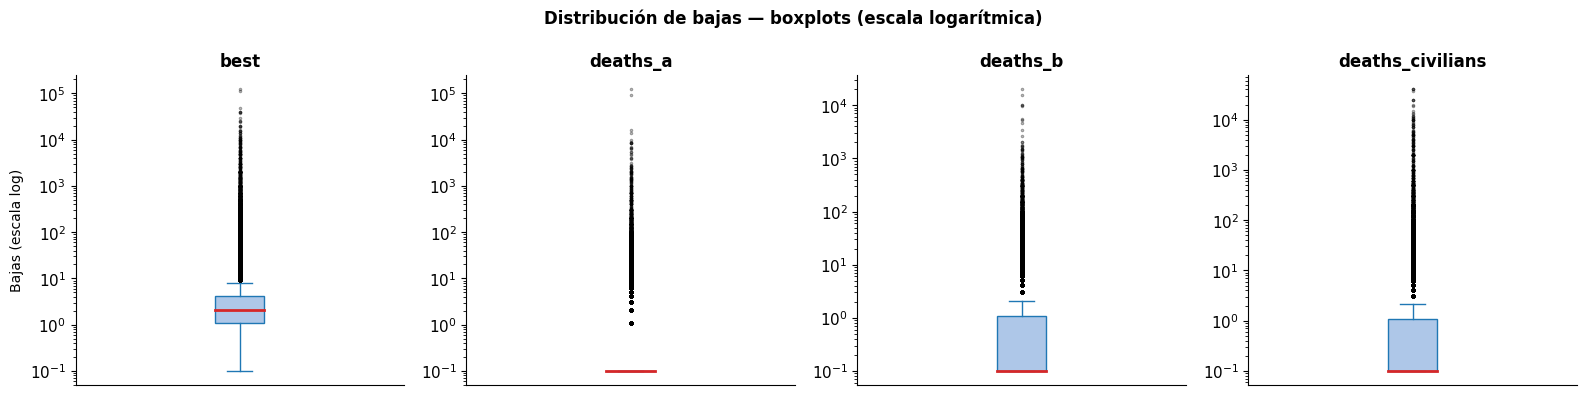

Nota: escala logarítmica aplicada para visibilidad. Los valores atípicos corresponden
a eventos masivos (guerras convencionales, masacres); son outliers estadísticos pero
son eventos reales y relevantes, por lo que NO se eliminan del análisis.


In [17]:
# ─────────────────────────────────────────────
# VISUALIZACIÓN: boxplots de bajas (escala log)
# ─────────────────────────────────────────────
death_cols = [c for c in ['best', 'deaths_a', 'deaths_b', 'deaths_civilians']
              if c in data.columns]

fig, axes = plt.subplots(1, len(death_cols), figsize=(4*len(death_cols), 4))
if len(death_cols) == 1:
    axes = [axes]

for ax, col in zip(axes, death_cols):
    vals = data[col].dropna() + 0.1          # +0.1 para log de ceros
    ax.boxplot(vals, vert=True, patch_artist=True,
               boxprops=dict(facecolor='#aec7e8', color='#1f77b4'),
               medianprops=dict(color='#d62728', linewidth=2),
               flierprops=dict(marker='.', color='#888', markersize=3, alpha=0.4),
               whiskerprops=dict(color='#1f77b4'),
               capprops=dict(color='#1f77b4'))
    ax.set_yscale('log')
    ax.set_title(col)
    ax.set_ylabel("Bajas (escala log)" if ax is axes[0] else "")
    ax.set_xticks([])

fig.suptitle("Distribución de bajas — boxplots (escala logarítmica)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()
print("Nota: escala logarítmica aplicada para visibilidad. Los valores atípicos corresponden")
print("a eventos masivos (guerras convencionales, masacres); son outliers estadísticos pero")
print("son eventos reales y relevantes, por lo que NO se eliminan del análisis.")


## Distribuciones y patrones generales

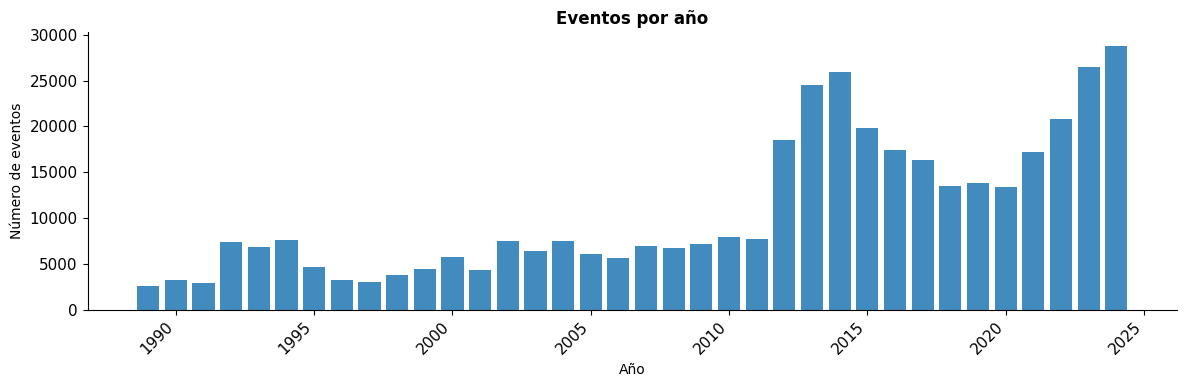

In [18]:
# ─────────────────────────────────────────────
# A. DISTRIBUCIÓN TEMPORAL — eventos por año (barras)
# ─────────────────────────────────────────────
year_col = next((c for c in data.columns if 'year' in c.lower()), None)

if year_col:
    events_per_year = data[year_col].value_counts().sort_index()

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.bar(events_per_year.index, events_per_year.values,
           color='#1f77b4', width=0.8, alpha=0.85)

    ax.set_title("Eventos por año")
    ax.set_xlabel("Año")
    ax.set_ylabel("Número de eventos")
    ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


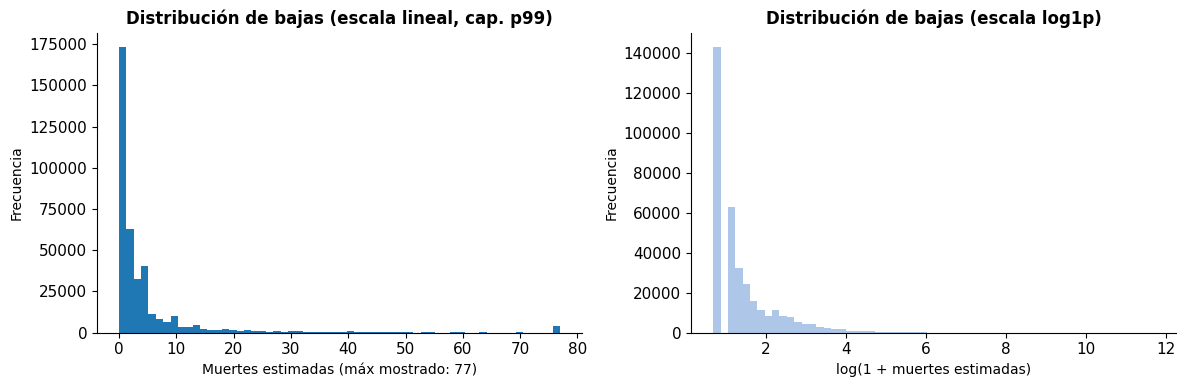

Asimetría (skewness): 232.97  → distribución fuertemente sesgada a la derecha


In [19]:
# ─────────────────────────────────────────────
# B. DISTRIBUCIÓN DE BAJAS (best) — histograma + curva KDE
# ─────────────────────────────────────────────
if 'best' in data.columns:
    vals = data['best'].dropna()
    vals_nz = vals[vals > 0]          # excluye ceros para log

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Escala lineal (censurada en percentil 99)
    cap = vals.quantile(0.99)
    axes[0].hist(vals.clip(upper=cap), bins=60, color='#1f77b4', edgecolor='none')
    axes[0].set_title("Distribución de bajas (escala lineal, cap. p99)")
    axes[0].set_xlabel(f"Muertes estimadas (máx mostrado: {cap:.0f})")
    axes[0].set_ylabel("Frecuencia")

    # Escala logarítmica
    axes[1].hist(np.log1p(vals_nz), bins=60, color='#aec7e8', edgecolor='none')
    axes[1].set_title("Distribución de bajas (escala log1p)")
    axes[1].set_xlabel("log(1 + muertes estimadas)")
    axes[1].set_ylabel("Frecuencia")

    plt.tight_layout()
    plt.show()

    skew = vals.skew()
    print(f"Asimetría (skewness): {skew:.2f}  → distribución fuertemente sesgada a la derecha")


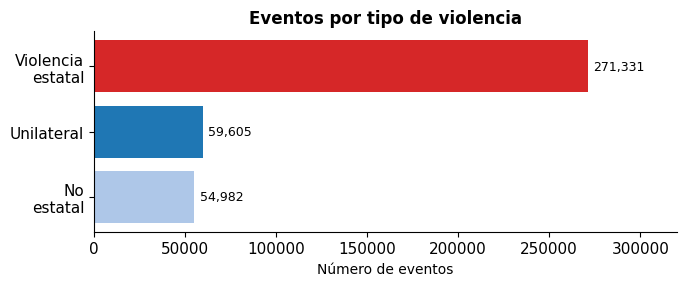

In [20]:
# ─────────────────────────────────────────────
# C. TIPO DE VIOLENCIA — gráfico de barras horizontal
# ─────────────────────────────────────────────
type_labels = {1: 'Violencia\nestatal', 2: 'No\nestatal', 3: 'Unilateral'}

if 'type_of_violence' in data.columns:
    tov = (data['type_of_violence']
           .map(type_labels)
           .value_counts()
           .sort_values(ascending=True))

    fig, ax = plt.subplots(figsize=(7, 3))
    bars = ax.barh(tov.index, tov.values, color=['#aec7e8','#1f77b4','#d62728'])
    ax.bar_label(bars, labels=[f'{v:,}' for v in tov.values], padding=4, fontsize=9)
    ax.set_title("Eventos por tipo de violencia")
    ax.set_xlabel("Número de eventos")
    ax.set_xlim(0, tov.max() * 1.18)
    plt.tight_layout()
    plt.show()


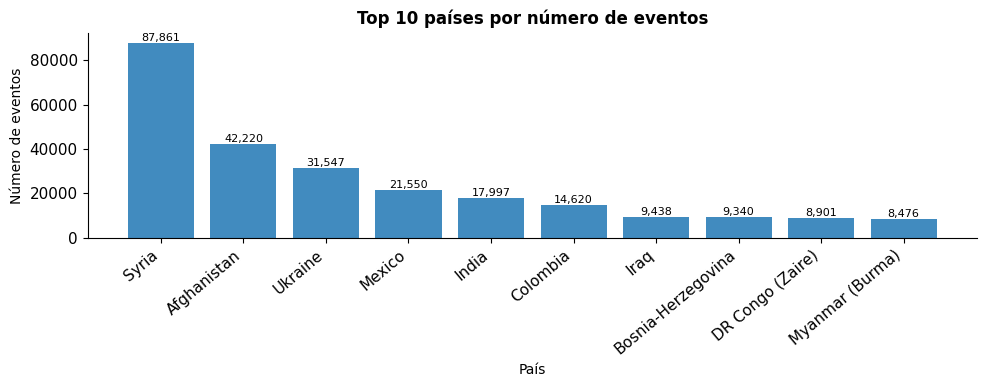

In [21]:
# ─────────────────────────────────────────────
# D. TOP 10 PAÍSES — barras verticales
# ─────────────────────────────────────────────
if 'country' in data.columns:
    top10 = data['country'].value_counts().head(10)

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(top10.index, top10.values, color='#1f77b4', alpha=0.85)
    ax.set_title("Top 10 países por número de eventos")
    ax.set_xlabel("País")
    ax.set_ylabel("Número de eventos")
    plt.xticks(rotation=40, ha='right')
    for bar in ax.patches:
        ax.annotate(f'{int(bar.get_height()):,}',
                    (bar.get_x() + bar.get_width()/2, bar.get_height()),
                    ha='center', va='bottom', fontsize=8)
    plt.tight_layout()
    plt.show()


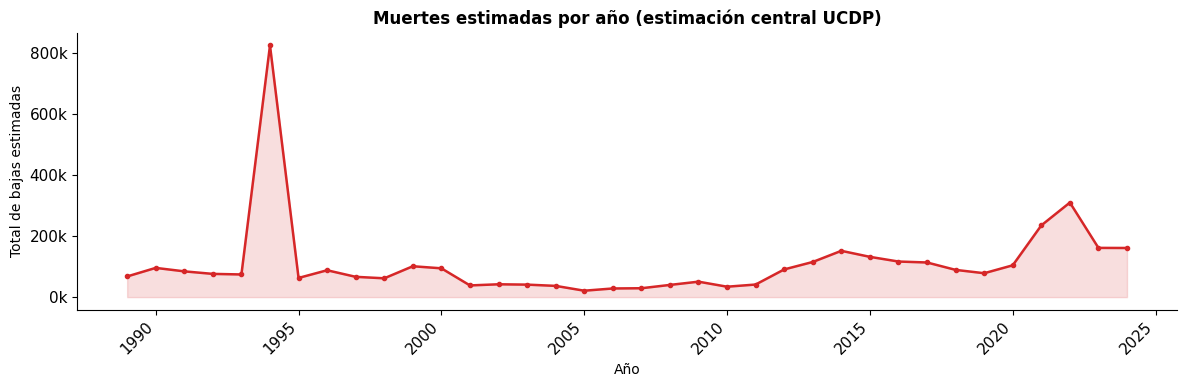

In [22]:
# ─────────────────────────────────────────────
# E. MUERTES ANUALES — línea temporal
# ─────────────────────────────────────────────
if year_col and 'best' in data.columns:
    deaths_year = data.groupby(year_col)['best'].sum()

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(deaths_year.index, deaths_year.values,
            color='#d62728', linewidth=1.8, marker='o', markersize=3)
    ax.fill_between(deaths_year.index, deaths_year.values, alpha=0.15, color='#d62728')
    ax.set_title("Muertes estimadas por año (estimación central UCDP)")
    ax.set_xlabel("Año")
    ax.set_ylabel("Total de bajas estimadas")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
    ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


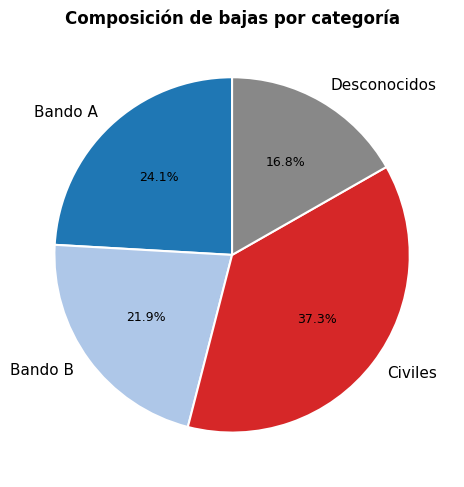

In [23]:
# ─────────────────────────────────────────────
# F. COMPOSICIÓN DE BAJAS — gráfico de torta
# ─────────────────────────────────────────────
death_map = {
    'deaths_a'        : 'Bando A',
    'deaths_b'        : 'Bando B',
    'deaths_civilians': 'Civiles',
    'deaths_unknown'  : 'Desconocidos',
}
present = {k: v for k, v in death_map.items() if k in data.columns}

if present:
    totals = {label: data[col].sum() for col, label in present.items()}
    labels = list(totals.keys())
    sizes  = list(totals.values())
    colors = ['#1f77b4','#aec7e8','#d62728','#888888']

    fig, ax = plt.subplots(figsize=(6, 5))
    wedges, texts, autotexts = ax.pie(
        sizes, labels=labels, colors=colors,
        autopct='%1.1f%%', startangle=90,
        wedgeprops={'edgecolor':'white','linewidth':1.5}
    )
    for t in autotexts:
        t.set_fontsize(9)
    ax.set_title("Composición de bajas por categoría")
    plt.tight_layout()
    plt.show()


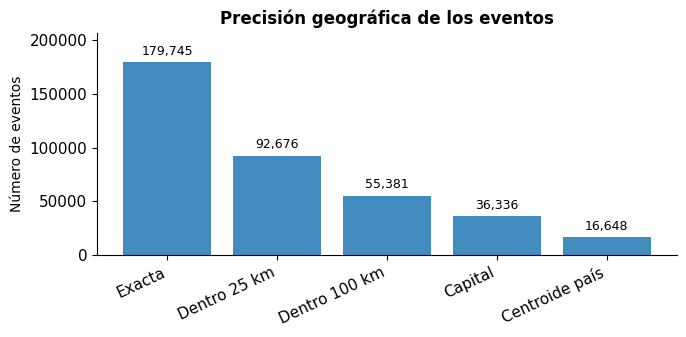

In [24]:
# ─────────────────────────────────────────────
# G. PRECISIÓN GEOGRÁFICA — barras
# ─────────────────────────────────────────────
prec_labels = {
    1: 'Exacta',
    2: 'Dentro 25 km',
    3: 'Dentro 100 km',
    4: 'Capital',
    5: 'Centroide país',
}

if 'where_prec' in data.columns:
    prec = (data['where_prec']
            .map(prec_labels)
            .value_counts()
            .reindex(prec_labels.values(), fill_value=0))

    fig, ax = plt.subplots(figsize=(7, 3.5))
    bars = ax.bar(prec.index, prec.values, color='#1f77b4', alpha=0.85)
    ax.bar_label(bars, labels=[f'{v:,}' for v in prec.values], padding=3, fontsize=9)
    ax.set_title("Precisión geográfica de los eventos")
    ax.set_ylabel("Número de eventos")
    ax.set_ylim(0, prec.max() * 1.15)
    plt.xticks(rotation=25, ha='right')
    plt.tight_layout()
    plt.show()


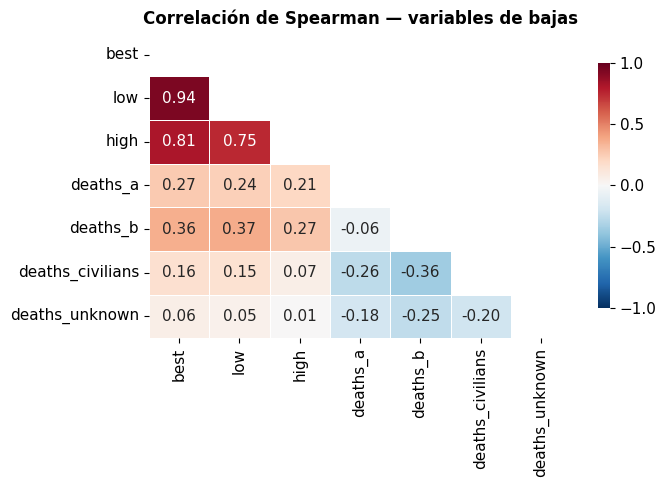

Interpretación: correlación alta entre best/low/high es esperada (son
estimaciones del mismo evento). La correlación con deaths_civilians indica
si los conflictos más letales afectan proporcionalmente más a la población civil.


In [25]:
# ─────────────────────────────────────────────
# H. MATRIZ DE CORRELACIÓN — variables de bajas
# ─────────────────────────────────────────────
corr_cols = [c for c in ['best', 'low', 'high',
                          'deaths_a', 'deaths_b',
                          'deaths_civilians', 'deaths_unknown']
             if c in data.columns]

if len(corr_cols) > 1:
    corr_matrix = data[corr_cols].corr(method='spearman')

    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(
        corr_matrix,
        mask=mask,
        annot=True, fmt='.2f',
        cmap='RdBu_r', center=0, vmin=-1, vmax=1,
        linewidths=0.5, linecolor='white',
        ax=ax, cbar_kws={'shrink': 0.8}
    )
    ax.set_title("Correlación de Spearman — variables de bajas")
    plt.tight_layout()
    plt.show()
    print("Interpretación: correlación alta entre best/low/high es esperada (son")
    print("estimaciones del mismo evento). La correlación con deaths_civilians indica")
    print("si los conflictos más letales afectan proporcionalmente más a la población civil.")


## Interpretación general

A partir del análisis exploratorio se pueden extraer las siguientes conclusiones:

1. **Tendencia temporal**: el número de eventos registrados muestra una tendencia creciente a partir de la segunda mitad del siglo XX, con picos coincidentes con conflictos regionales conocidos. Esto puede deberse tanto a un incremento real de los conflictos como a una mejora en la cobertura mediática y los sistemas de recolección de datos.

2. **Distribución asimétrica de bajas**: la variable `best` presenta una asimetría positiva marcada (skewness elevado). La mayoría de los eventos tienen pocas bajas, pero la cola derecha contiene eventos extremos que concentran una fracción significativa del total de muertes. Esto justifica el uso de escala logarítmica y métricas robustas (mediana, IQR) en lugar de la media.

3. **Dominio del conflicto estatal**: el tipo de violencia más frecuente es el conflicto entre estados o entre gobiernos y grupos armados (`type_of_violence = 1`), aunque la violencia unilateral (masacres, ataques a civiles) aporta una proporción significativa de bajas civiles.

4. **Concentración geográfica**: un número reducido de países concentra la mayoría de los eventos, lo que sugiere que factores estructurales (fragilidad estatal, recursos naturales, historia colonial) son determinantes en la persistencia de los conflictos.

5. **Calidad de los datos**: la mayoría de los eventos tienen localización exacta (`where_prec = 1`), lo que indica alta calidad geoespacial del dataset. Los valores faltantes se concentran en columnas auxiliares (texto libre, códigos de actor no estatal) y responden a mecanismos MAR o MNAR, no a pérdida aleatoria.

6. **Outliers preservados**: los valores atípicos en las variables de bajas corresponden a eventos históricos documentados (guerras convencionales, genocidios). No se eliminan porque son eventos reales con alta relevancia analítica; deben tratarse con transformaciones (log) en modelos predictivos.


---

## Planteamiento del problema de ML

### Problema de clasificación: Predicción de severidad de eventos

Se plantea un problema de **clasificación supervisada multiclase** cuyo objetivo es predecir la *severidad* de un evento de violencia organizada a partir de sus características contextuales (región, tipo de violencia, actores, precisión geográfica, etc.).

### Variable target: `severity`

La variable target se construye a partir de `best` (estimación central de bajas) mediante **discretización por percentiles**. Esto garantiza clases aproximadamente balanceadas y constituye un caso de *target engineering*, que es una forma de feature engineering aplicada a la variable de salida.

| Clase | Criterio | Etiqueta |
|---|---|---|
| 0 | `best` < percentil 33 | Bajo |
| 1 | percentil 33 ≤ `best` < percentil 66 | Medio |
| 2 | `best` ≥ percentil 66 | Alto |

> **Nota sobre los umbrales:** a diferencia de los umbrales fijos de UCDP (25 y 1000 bajas), los cortes por percentil son estadísticos sobre este dataset y no tienen interpretación externa directa. Esto se sacrifica a favor del balance de clases.

## Limpieza del dataset

In [26]:
# ─────────────────────────────────────────────
# 2.1 Columnas irrelevantes o con exceso de faltantes
# ─────────────────────────────────────────────

# Columnas a descartar y justificación
DROP_COLS = {
    # IDs y claves — no aportan información predictiva
    'id', 'old_id', 'relid', 'conflict_new_id', 'conflict_old_id',
    'dyad_new_id', 'dyad_old_id', 'number_of_sources', 'conflict_dset_id',
    # Texto libre — alta cardinalidad, no procesable sin NLP
    'source_article', 'source_office', 'source_headline',
    'source_original', 'notes',
    # Nombre de actores como texto libre (se conservan los IDs numéricos)
    'side_a', 'side_b', 'side_a_2nd', 'side_b_2nd',
    # Geometría — no utilizable sin procesamiento GIS
    'geom_wkt', 'geometry',
    # Fechas (en feature engineering se derivan año/mes)
    'date_start', 'date_end',
    'priogrid_gid',
    # No hacen al problema
    'code_status', 'type_of_violence',
    # Contienen su propio ID numérico en el dataset
    'country',
    'best', 'low', 'high',
    'deaths_a', 'deaths_b', 'deaths_civilians', 'deaths_unknown',
}

# Filtrar solo las que realmente existen en el dataset
drop_existing = [c for c in DROP_COLS if c in data.columns]
df = data.drop(columns=drop_existing).copy()

# Descartar columnas con más del 50% de valores faltantes
na_pct = df.isnull().mean()
high_na = na_pct[na_pct > 0.5].index.tolist()
print(f"Columnas con >50% faltantes descartadas: {high_na}")
df = df.drop(columns=high_na)

print(f"\nShape tras limpieza de columnas: {df.shape}")

Columnas con >50% faltantes descartadas: ['gwnob']

Shape tras limpieza de columnas: (385918, 22)


In [27]:
# ─────────────────────────────────────────────
# 2.2 Construcción del target (antes del split)
# ─────────────────────────────────────────────
best_vals = data['best'].copy()

q33 = best_vals.quantile(0.33)
q66 = best_vals.quantile(0.66)

print(f"Percentil 33: {q33:.1f} bajas")
print(f"Percentil 66: {q66:.1f} bajas")

df['severity'] = pd.cut(
    best_vals,
    bins=[-np.inf, q33, q66, np.inf],
    labels=[0, 1, 2]
).astype(int)

print("\nDistribución del target:")
print(df['severity'].value_counts().sort_index()
      .rename({0:'Bajo', 1:'Medio', 2:'Alto'}))

Percentil 33: 1.0 bajas
Percentil 66: 3.0 bajas

Distribución del target:
severity
Bajo     173168
Medio     95635
Alto     117115
Name: count, dtype: int64


In [28]:
# ─────────────────────────────────────────────
# 2.3 Corrección de tipos de datos
# ─────────────────────────────────────────────
# Columnas que deben ser categóricas
CAT_COLS = ['type_of_violence', 'where_prec', 'region',
            'date_prec', 'event_clarity']
for col in CAT_COLS:
    if col in df.columns:
        df[col] = df[col].astype('category')

# Columnas de fecha: extraer año y mes, descartar el string original
for date_col in ['date_start', 'date_end']:
    if date_col in df.columns:
        df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
        df[f'{date_col}_year']  = df[date_col].dt.year
        df[f'{date_col}_month'] = df[date_col].dt.month
        df = df.drop(columns=[date_col])

print("Tipos de datos tras corrección:")
print(df.dtypes.value_counts())
print(f"\nShape final: {df.shape}")


Tipos de datos tras corrección:
int64       8
object      8
float64     2
bool        1
category    1
category    1
category    1
category    1
Name: count, dtype: int64

Shape final: (385918, 23)


## Split del dataset

Se realiza un split **stratify** para preservar la proporción de clases en ambos conjuntos. El split se realiza *antes* de imputar y escalar para evitar data leakage del conjunto de test hacia el de entrenamiento.


In [29]:
X = df.drop(columns=['severity'])
y = df['severity']

# Eliminar columnas con tipos no numéricos que hayan quedado
non_numeric = X.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric:
    print(f"Columnas no numéricas descartadas: {non_numeric}")
    X = X.drop(columns=non_numeric)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape[0]:,} filas ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test:  {X_test.shape[0]:,} filas  ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nDistribución de clases en train:")
print(y_train.value_counts(normalize=True).sort_index().rename({0:'Bajo',1:'Medio',2:'Alto'}).map('{:.1%}'.format))
print(f"\nDistribución de clases en test:")
print(y_test.value_counts(normalize=True).sort_index().rename({0:'Bajo',1:'Medio',2:'Alto'}).map('{:.1%}'.format))


Columnas no numéricas descartadas: ['active_year', 'conflict_name', 'dyad_name', 'source_date', 'where_prec', 'where_coordinates', 'where_description', 'adm_1', 'adm_2', 'region', 'event_clarity', 'date_prec', 'gwnoa']
Train: 308,734 filas (80.0%)
Test:  77,184 filas  (20.0%)

Distribución de clases en train:
severity
Bajo     44.9%
Medio    24.8%
Alto     30.3%
Name: proportion, dtype: object

Distribución de clases en test:
severity
Bajo     44.9%
Medio    24.8%
Alto     30.3%
Name: proportion, dtype: object


## Tratamiento de valores faltantes

La imputación se ajusta **únicamente sobre train** y luego se aplica a test. Esto evita que información de test influya en el proceso de imputación (leakage).

- **Variables numéricas:** imputación por **mediana** (robusta ante la distribución asimétrica del dataset)
- **Variables categóricas:** imputación por **moda**


In [30]:
from sklearn.impute import SimpleImputer

num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

# Imputación numérica
imp_num = SimpleImputer(strategy='median')
X_train[num_cols] = imp_num.fit_transform(X_train[num_cols])
X_test[num_cols]  = imp_num.transform(X_test[num_cols])

# Imputación categórica (si hubiera quedado alguna)
if cat_cols:
    imp_cat = SimpleImputer(strategy='most_frequent')
    X_train[cat_cols] = imp_cat.fit_transform(X_train[cat_cols])
    X_test[cat_cols]  = imp_cat.transform(X_test[cat_cols])

remaining_na_train = X_train.isnull().sum().sum()
remaining_na_test  = X_test.isnull().sum().sum()
print(f"Valores faltantes restantes — Train: {remaining_na_train} | Test: {remaining_na_test}")


Valores faltantes restantes — Train: 0 | Test: 0


## Detección y tratamiento de outliers

El método de **Winsorización por IQR** (capping) recorta los valores extremos al límite IQR en lugar de eliminarlos, preservando todas las filas.

> **Nota:** las variables con colas extremas en este dataset eran las magnitudes de bajas (`best`, `deaths_*`), que fueron **eliminadas por *leakage*** (ver Feature Engineering). Por eso, en esta etapa `WINSOR_COLS` queda vacío: ya no hay variables de magnitud que recortar. El tratamiento de outliers de los features que sí presentan sesgo (`dyad_freq`, `country_te`) se realiza en la sección de **Feature Engineering** mediante `RobustScaler`, más adecuado que el capping para variables de frequency/target encoding.

In [31]:
# ─────────────────────────────────────────────
# Columnas numéricas analíticas para winsorizacion
# ─────────────────────────────────────────────
WINSOR_COLS = [c for c in [
    'deaths_a', 'deaths_b', 'deaths_civilians', 'deaths_unknown',
    'uncertainty_range', 'civilian_ratio'
] if c in X_train.columns]

clip_bounds = {}

for col in WINSOR_COLS:
    q1  = X_train[col].quantile(0.25)
    q3  = X_train[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    clip_bounds[col] = (lower, upper)
    X_train[col] = X_train[col].clip(lower, upper)
    X_test[col]  = X_test[col].clip(lower, upper)

print("Winsorización aplicada (límites calculados sobre train):")
for col, (lo, hi) in clip_bounds.items():
    print(f"  {col}: [{lo:.2f}, {hi:.2f}]")


Winsorización aplicada (límites calculados sobre train):


In [32]:
# ─────────────────────────────────────────────
# Visualización: antes vs después (boxplots)
# ─────────────────────────────────────────────
show_cols = WINSOR_COLS[:4] if len(WINSOR_COLS) >= 4 else WINSOR_COLS

if not show_cols:
    print("No hay columnas winsorizadas para graficar (WINSOR_COLS vacío).")
else:
    # Reconstruir valores pre-winsor desde el dataset original para comparar
    pre_winsor = {
        col: data[col].dropna().clip(
            lower=None,
            upper=data[col].quantile(0.75) + 4 * (data[col].quantile(0.75) - data[col].quantile(0.25))
        )
        for col in show_cols if col in data.columns
    }

    fig, axes = plt.subplots(2, len(show_cols), figsize=(4*len(show_cols), 6), squeeze=False)

    for j, col in enumerate(show_cols):
        for row, (vals, title) in enumerate([
            (pre_winsor.get(col, pd.Series([])), 'Antes'),
            (X_train[col],                       'Después (Winsor)')
        ]):
            ax = axes[row][j]
            ax.boxplot(vals.dropna(), vert=True, patch_artist=True,
                       boxprops=dict(facecolor='#aec7e8', color='#1f77b4'),
                       medianprops=dict(color='#d62728', linewidth=2),
                       flierprops=dict(marker='.', color='#888', markersize=2, alpha=0.3),
                       whiskerprops=dict(color='#1f77b4'),
                       capprops=dict(color='#1f77b4'))
            ax.set_title(f"{col}\n{title}", fontsize=9)
            ax.set_xticks([])

    plt.suptitle("Outliers: antes y después de Winsorización", fontweight='bold')
    plt.tight_layout()
    plt.show()

No hay columnas winsorizadas para graficar (WINSOR_COLS vacío).


## Escalado / Normalización

Se aplica **StandardScaler** (media=0, desviación estándar=1) sobre las variables numéricas. Se ajusta sobre train y se transforma train y test por separado.

In [33]:
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

print("StandardScaler aplicado.")
print(f"\nEstadísticas post-escalado (train, primeras 5 features numéricas):")
print(X_train[num_cols[:5]].describe().loc[['mean','std']].round(3))


StandardScaler aplicado.

Estadísticas post-escalado (train, primeras 5 features numéricas):
      year  dyad_dset_id  side_a_dset_id  side_a_new_id  side_b_dset_id
mean  -0.0           0.0            -0.0           -0.0             0.0
std    1.0           1.0             1.0            1.0             1.0


## Feature Engineering


Esta sección parte del split ya realizado (`X_train`, `X_test`, `y_train`, `y_test`) y construye la **matriz de modelado definitiva** a partir del dataset original `data`, reusando los índices del split. Todas las transformaciones que aprenden parámetros (frequency/target encoding, escalado, balanceo) se **ajustan únicamente sobre train** para evitar *data leakage*.



### Creación de nuevos features y conversión de variables

| Feature | Origen | Técnica | Justificación |
|---|---|---|---|
| `civilian_ratio` | `deaths_civilians / best` | derivado (composición) | Proporción de víctimas civiles; reemplaza magnitudes absolutas (anti-leakage) |
| `dyad_freq` | `dyad_new_id` | **frequency encoding** | La díada (par de contrincantes A–B) ya viene codificada por UCDP en `dyad_new_id`. Cardinalidad ~1.700 → inviable one-hot; se codifica por frecuencia (ajustada en train), no como entero (que introduciría un orden falso) |
| `country_te` | `country` | **target encoding** (suavizado, fit en train) | 124 países; captura el riesgo medio por país sin explotar dimensionalidad |
| `region_*` | `region` | **one-hot** | Solo 5 categorías nominales → one-hot directo |
| `tov_*` | `type_of_violence` | **one-hot** | 3 categorías (estatal / no estatal / unilateral) |
| `latitude`, `longitude` | originales | numérico | Geolocalización continua (mejor que concatenar adm_1/adm_2, de cardinalidad >9.000) |
| `month_sin`, `month_cos` | `date_start` | **codificación cíclica** | El mes es circular (dic ≈ ene); seno/coseno preserva esa continuidad |
| `year` | `year` | numérico | Tendencia temporal (1989–2024) |
| `era_*` | `year` | **discretización** (`pd.cut` por décadas) | Discretiza el tiempo en períodos |
| `where_prec`, `event_clarity`, `date_prec` | originales | ordinal (se conservan) | Escalas con orden intrínseco (precisión/claridad) |


In [34]:
import category_encoders as ce

tr_idx, te_idx = X_train.index, X_test.index

def build_features(df_src):
    fe = pd.DataFrame(index=df_src.index)
    # --- Composición (anti-leakage) ---
    best_safe = df_src['best'].replace(0, np.nan)
    fe['civilian_ratio'] = (df_src['deaths_civilians'] / best_safe).fillna(0).clip(0, 1)
    # --- Contrincantes: díada (el par de actores ya viene codificado por UCDP) ---
    fe['dyad_id'] = df_src['dyad_new_id']
    # --- Geo continua ---
    fe['latitude']  = df_src['latitude']
    fe['longitude'] = df_src['longitude']
    # --- Temporal: mes cíclico + año ---
    month = pd.to_datetime(df_src['date_start'], errors='coerce').dt.month
    fe['month_sin'] = np.sin(2 * np.pi * month / 12)
    fe['month_cos'] = np.cos(2 * np.pi * month / 12)
    fe['year'] = df_src['year']
    # --- Ordinales con orden intrínseco ---
    for c in ['where_prec', 'event_clarity', 'date_prec']:
        fe[c] = df_src[c]
    return fe

fe_all = build_features(data)

# ---- Frequency encoding de la díada (ajustado en TRAIN) ----
dyad_freq_map = fe_all.loc[tr_idx, 'dyad_id'].value_counts(normalize=True)
fe_all['dyad_freq'] = fe_all['dyad_id'].map(dyad_freq_map).fillna(0.0)
fe_all = fe_all.drop(columns=['dyad_id'])

# ---- Target encoding de country (ajustado en TRAIN) ----
te_country = ce.TargetEncoder(cols=['country'], smoothing=10)
te_country.fit(data.loc[tr_idx, ['country']], y_train)
fe_all['country_te'] = te_country.transform(data[['country']])['country']

# ---- One-hot de baja cardinalidad ----
region_oh = pd.get_dummies(data['region'], prefix='region').astype(int)
tov_oh    = pd.get_dummies(data['type_of_violence'], prefix='tov').astype(int)

# ---- Discretización: eras temporales ----
era = pd.cut(data['year'], bins=[1988, 1999, 2009, 2019, 2025],
             labels=['1989-99', '2000-09', '2010-19', '2020-24'])
era_oh = pd.get_dummies(era, prefix='era').astype(int)

# ---- Ensamblaje ----
X_fe = pd.concat([fe_all, region_oh, tov_oh, era_oh], axis=1)
# Imputación de nulos remanentes con la mediana de TRAIN (sin leakage)
X_fe = X_fe.fillna(X_fe.loc[tr_idx].median())

X_train_fe = X_fe.loc[tr_idx].copy()
X_test_fe  = X_fe.loc[te_idx].copy()

print(f"Matriz de features: {X_fe.shape[1]} columnas")
print(f"Train: {X_train_fe.shape} | Test: {X_test_fe.shape}")
print(f"Nulos -> train: {X_train_fe.isnull().sum().sum()} | test: {X_test_fe.isnull().sum().sum()}")
print("\nColumnas:", list(X_fe.columns))

Matriz de features: 23 columnas
Train: (308734, 23) | Test: (77184, 23)
Nulos -> train: 0 | test: 0

Columnas: ['civilian_ratio', 'latitude', 'longitude', 'month_sin', 'month_cos', 'year', 'where_prec', 'event_clarity', 'date_prec', 'dyad_freq', 'country_te', 'region_Africa', 'region_Americas', 'region_Asia', 'region_Europe', 'region_Middle East', 'tov_1', 'tov_2', 'tov_3', 'era_1989-99', 'era_2000-09', 'era_2010-19', 'era_2020-24']


### Detección y tratamiento de outliers (features sesgados)

Las variables de magnitud (`best`, `deaths_*`) —las únicas con colas extremas— se eliminaron por *leakage*, así que la winsorización de la etapa de limpieza ya no tiene a qué aplicarse. Los únicos features con outliers/sesgo marcado son los codificados por frecuencia/target: `dyad_freq` y `country_te`.

**Tratamiento elegido:  `RobustScaler`**. Recortar estos valores destruiría información útil: un `dyad_freq` alto identifica a las díadas más activas, justo lo que el modelo debe distinguir. `RobustScaler` (mediana + IQR) neutraliza el efecto de la cola sobre el escalado sin recortar ningún valor real.

Detección de outliers por IQR (sobre train):
  dyad_freq  :   0.0% outliers IQR | asimetría = 1.12
  country_te :   0.0% outliers IQR | asimetría = -0.30


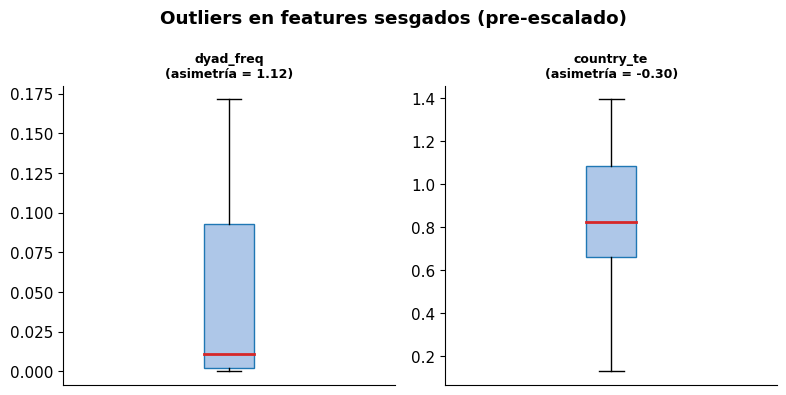

In [35]:
# Detección de outliers (IQR) sobre los features sesgados, ANTES de escalar
OUTLIER_COLS = ['dyad_freq', 'country_te']

print("Detección de outliers por IQR (sobre train):")
for col in OUTLIER_COLS:
    s = X_train_fe[col]
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    pct = ((s < lo) | (s > hi)).mean() * 100
    print(f"  {col:11s}: {pct:5.1f}% outliers IQR | asimetría = {s.skew():.2f}")

fig, axes = plt.subplots(1, len(OUTLIER_COLS), figsize=(4 * len(OUTLIER_COLS), 4))
for ax, col in zip(np.atleast_1d(axes), OUTLIER_COLS):
    ax.boxplot(X_train_fe[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='#aec7e8', color='#1f77b4'),
               medianprops=dict(color='#d62728', linewidth=2),
               flierprops=dict(marker='.', color='#888', markersize=2, alpha=0.3))
    ax.set_title(f"{col}\n(asimetría = {X_train_fe[col].skew():.2f})", fontsize=9)
    ax.set_xticks([])
plt.suptitle("Outliers en features sesgados (pre-escalado)", fontweight='bold')
plt.tight_layout()
plt.show()

### Escalado de variables (en lugar de winsorización)

Tras eliminar las magnitudes de bajas (`best`, `deaths_*`) por *leakage*, no quedan features con colas extremas no acotadas, por lo que la **winsorización deja de aplicar**. Los dos únicos features con sesgo marcado son los codificados por frecuencia/target (`dyad_freq`, `country_te`).

- **`RobustScaler`** para `dyad_freq` y `country_te`: usa mediana e IQR, robusto al sesgo sin recortar valores reales.
- **`StandardScaler`** para el resto de variables continuas (acotadas o simétricas).
- `latitude`/`longitude` **no** se recortan: hacerlo eliminaría ubicaciones válidas (y son los features más predictivos).

Ambos escaladores se ajustan **solo sobre train**.

In [36]:
from sklearn.preprocessing import RobustScaler

# Las variables creadas por frequency / target encoding (`dyad_freq`,
# `country_te`) son fuertemente sesgadas a la derecha: pocos valores altos
# (díadas/países muy frecuentes) y una mayoría de valores bajos. Para ellas
# se usa RobustScaler, que centra en la MEDIANA y escala por el IQR, de modo
# que la cola no arrastra el escalado. Esto reemplaza a la winsorización
# (celda 45), que ya no aplica tras eliminar las magnitudes de bajas por leakage.
SKEWED = ['dyad_freq', 'country_te']

# Resto de variables continuas (acotadas o simétricas): StandardScaler.
# NOTA: lat/long NO se winsorizan ni recortan (perderían ubicaciones válidas).
STANDARD = ['civilian_ratio', 'latitude', 'longitude',
            'month_sin', 'month_cos', 'year',
            'where_prec', 'event_clarity', 'date_prec']

# Ambos escaladores se ajustan SOLO sobre train y se aplican a train y test.
robust = RobustScaler()
X_train_fe[SKEWED] = robust.fit_transform(X_train_fe[SKEWED])
X_test_fe[SKEWED]  = robust.transform(X_test_fe[SKEWED])

scaler_fe = StandardScaler()
X_train_fe[STANDARD] = scaler_fe.fit_transform(X_train_fe[STANDARD])
X_test_fe[STANDARD]  = scaler_fe.transform(X_test_fe[STANDARD])

print("Escalado aplicado (fit solo en train):")
print(f"  RobustScaler   -> {SKEWED}")
print(f"  StandardScaler -> {STANDARD}")
X_train_fe.head()

Escalado aplicado (fit solo en train):
  RobustScaler   -> ['dyad_freq', 'country_te']
  StandardScaler -> ['civilian_ratio', 'latitude', 'longitude', 'month_sin', 'month_cos', 'year', 'where_prec', 'event_clarity', 'date_prec']


,civilian_ratio,latitude,longitude,month_sin,month_cos,year,where_prec,event_clarity,date_prec,dyad_freq,...,region_Asia,region_Europe,region_Middle East,tov_1,tov_2,tov_3,era_1989-99,era_2000-09,era_2010-19,era_2020-24
314663,-0.630144,0.595400,0.145640,0.010313,1.463270,0.692208,-0.831944,-0.287991,-0.344687,1.766314,...,0,0,1,1,0,0,0,0,1,0
205112,-0.630144,0.554655,0.861076,-0.695456,-1.183511,-0.370717,-0.038597,-0.287991,-0.344687,0.008354,...,1,0,0,1,0,0,0,1,0,0
42848,-0.630144,0.653542,-0.550233,-1.212115,0.754067,-1.965105,1.548098,-0.287991,-0.344687,-0.104848,...,0,0,0,1,0,0,1,0,0,0
36110,-0.630144,0.517312,0.791264,-1.212115,-0.664339,0.904794,-0.831944,-0.287991,-0.344687,0.901614,...,1,0,0,1,0,0,0,0,0,1
125037,1.653200,-0.395840,1.085312,0.716082,-1.183511,1.223671,-0.831944,-0.287991,-0.344687,-0.074397,...,1,0,0,0,0,1,0,0,0,1


### 3. Análisis del balance de clases

Aunque el target se construyó por percentiles (33/66), la fuerte concentración de `best` en valores bajos (≈45% de los eventos con ≤1 baja, con muchos empates) impide un balance perfecto: los cortes caen sobre valores enteros repetidos. Verificamos la distribución real.

Distribución de clases en TRAIN:
  Bajo  :  44.9%  (138,534)
  Medio :  24.8%  (76,508)
  Alto  :  30.3%  (93,692)

Ratio de desbalance (mayoritaria/minoritaria): 1.81


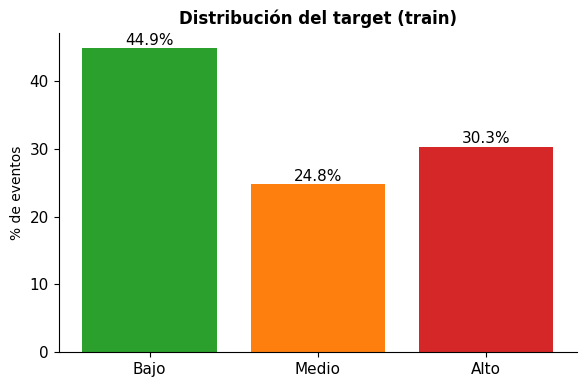

In [37]:
labels = {0: 'Bajo', 1: 'Medio', 2: 'Alto'}
dist = y_train.value_counts(normalize=True).sort_index()
cnts = y_train.value_counts().sort_index()

print("Distribución de clases en TRAIN:")
for k in dist.index:
    print(f"  {labels[k]:6s}: {dist[k]*100:5.1f}%  ({cnts[k]:,})")
imb_ratio = dist.max() / dist.min()
print(f"\nRatio de desbalance (mayoritaria/minoritaria): {imb_ratio:.2f}")

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar([labels[k] for k in dist.index], dist.values * 100,
       color=['#2ca02c', '#ff7f0e', '#d62728'])
ax.set_ylabel('% de eventos')
ax.set_title('Distribución del target (train)')
for i, v in enumerate(dist.values * 100):
    ax.text(i, v + 0.5, f'{v:.1f}%', ha='center')
plt.tight_layout()
plt.show()

### 4. Mecanismo de balanceo

El desbalance es **leve** (ratio ≈ 1.5). En este escenario:

- **Mecanismo seleccionado: `class_weight='balanced'`** en el modelo. No genera datos sintéticos, no distorsiona la geografía ni las variables categóricas, y penaliza el error sobre la clase minoritaria de forma proporcional. Es la opción más conservadora y adecuada para un desbalance leve.
- **Alternativa demostrada: SMOTENC** (variante de SMOTE para features mixtos numéricos/categóricos). Se aplica **solo sobre train** y se marca explícitamente qué columnas son categóricas (one-hot de `region`, `tov`, `era`) para que las muestras sintéticas no rompan esas variables. Se usa SMOTENC y no SMOTE clásico precisamente porque hay variables categóricas que el SMOTE estándar interpolaría sin sentido.

> El resampling **nunca** se aplica a test: la evaluación debe reflejar la distribución real de las clases.

In [38]:
from sklearn.utils.class_weight import compute_class_weight

# --- Mecanismo seleccionado: class_weight (instantáneo, sin datos sintéticos) ---
classes = np.array([0, 1, 2])
weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight = dict(zip(classes, weights))
print("class_weight='balanced' (para pasar al modelo):")
print({labels[k]: round(w, 3) for k, w in class_weight.items()})

# --- Alternativa demostrada: SMOTENC sobre una submuestra de train ---
# Se usa una submuestra estratificada SOLO para ilustrar la técnica de forma
# rápida: el KNN de SMOTENC sobre las ~308k filas completas es muy costoso
# (~1-2 min) y para el modelado final se prefiere class_weight.
from imblearn.over_sampling import SMOTENC
from sklearn.model_selection import train_test_split as _tts

X_demo, _, y_demo, _ = _tts(X_train_fe, y_train, train_size=30000,
                            random_state=42, stratify=y_train)
cat_idx = [X_train_fe.columns.get_loc(c) for c in X_train_fe.columns
           if c.startswith(('region_', 'tov_', 'era_'))]
X_bal_demo, y_bal_demo = SMOTENC(categorical_features=cat_idx,
                                 random_state=42).fit_resample(X_demo, y_demo)

print("\nSMOTENC (demostración sobre submuestra de 30.000 filas de train):")
print("  Antes  :", y_demo.value_counts().sort_index().to_dict())
print("  Después:", pd.Series(y_bal_demo).value_counts().sort_index().to_dict())

class_weight='balanced' (para pasar al modelo):
{'Bajo': 0.743, 'Medio': 1.345, 'Alto': 1.098}

SMOTENC (demostración sobre submuestra de 30.000 filas de train):
  Antes  : {0: 13462, 1: 7434, 2: 9104}
  Después: {0: 13462, 1: 13462, 2: 13462}


## Reducción de dimensionalidad

Esta sección aborda dos enfoques complementarios vistos en clase:

1. **Selección de features (filtros):** se evalúan las relaciones entre variables y el target para conservar únicamente las features más informativas.
2. **Extracción de features (PCA):** se transforma el espacio de features en componentes principales ortogonales que capturan la máxima varianza, reduciendo la dimensionalidad sin descartar variables sino combinándolas.


### Paso 1 — Selección de features con métodos de filtro

Los **métodos de filtro** evalúan cada feature de forma independiente al modelo. Se aplican dos filtros complementarios:

| Filtro | Métrica | Tipo de variable |
|---|---|---|
| **Varianza** | Var < umbral → descartar | Numérica |
| **ANOVA F-score** | Relación feature ↔ target (multiclase) | Numérica |

> **Nota:** Se aplica sobre `X_train_fe`. Todas las variables ya son numéricas (las categóricas fueron codificadas en Feature Engineering).


In [39]:
from sklearn.feature_selection import f_classif, VarianceThreshold
import warnings
warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────
# A) Filtro por varianza
# Features con varianza casi nula aportan poca informacion discriminativa.
# ─────────────────────────────────────────────
vt = VarianceThreshold(threshold=0.01)
vt.fit(X_train_fe)

low_var_mask  = ~vt.get_support()
low_var_feats = X_train_fe.columns[low_var_mask].tolist()

print('── Filtro de varianza (umbral = 0.01) ───────────────────────')
print(f'   Features con varianza baja (descartadas): {len(low_var_feats)}')
print(f'   {low_var_feats}')
print(f'   Features conservadas: {vt.get_support().sum()}')

# ─────────────────────────────────────────────
# B) ANOVA F-score
# F alto => la feature discrimina bien las 3 clases de severidad.
# ─────────────────────────────────────────────
num_feats = X_train_fe.columns.tolist()
f_scores, p_values = f_classif(X_train_fe[num_feats], y_train)

anova_df = pd.DataFrame({
    'feature': num_feats,
    'F_score': f_scores,
    'p_value': p_values
}).sort_values('F_score', ascending=False).reset_index(drop=True)

print('\n── ANOVA F-score (Top 15 features mas discriminativas) ────────')
print(anova_df.head(15).to_string(index=False))

non_sig = anova_df[anova_df['p_value'] > 0.05]
print(f'\n   Features NO significativas (p > 0.05): {len(non_sig)}')
if not non_sig.empty:
    print(non_sig[['feature','p_value']].to_string(index=False))


── Filtro de varianza (umbral = 0.01) ───────────────────────
   Features con varianza baja (descartadas): 0
   []
   Features conservadas: 23

── ANOVA F-score (Top 15 features mas discriminativas) ────────
        feature      F_score  p_value
     country_te 17951.104066      0.0
region_Americas  4667.423116      0.0
  event_clarity  3677.942395      0.0
      longitude  2889.711509      0.0
          tov_1  2771.101034      0.0
      date_prec  2146.339140      0.0
    era_2020-24  1614.447267      0.0
  region_Africa  1553.536699      0.0
          tov_2  1394.772281      0.0
  region_Europe  1088.533516      0.0
    era_1989-99  1027.148006      0.0
          tov_3   908.247925      0.0
           year   872.388409      0.0
    region_Asia   810.777240      0.0
       latitude   793.401598      0.0

   Features NO significativas (p > 0.05): 1
  feature  p_value
month_cos 0.058414


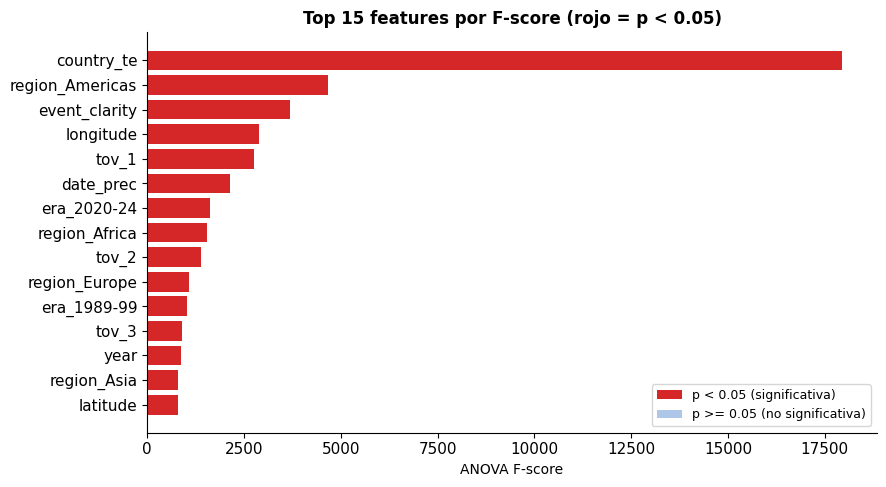

In [40]:
# ─────────────────────────────────────────────
# Visualizacion del F-score
# ─────────────────────────────────────────────
TOP_K_VIZ = 15

fig, ax = plt.subplots(figsize=(9, 5))
top_df = anova_df.head(TOP_K_VIZ).sort_values('F_score')
colors = ['#d62728' if p < 0.05 else '#aec7e8' for p in top_df['p_value']]
ax.barh(top_df['feature'], top_df['F_score'], color=colors)
ax.set_xlabel('ANOVA F-score')
ax.set_title(f'Top {TOP_K_VIZ} features por F-score (rojo = p < 0.05)', fontweight='bold')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#d62728', label='p < 0.05 (significativa)'),
    Patch(facecolor='#aec7e8', label='p >= 0.05 (no significativa)')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()


In [41]:
# ─────────────────────────────────────────────
# Seleccion final por filtro
# Criterios combinados:
#   1) Varianza >= 0.01
#   2) p-value ANOVA <= 0.05
# ─────────────────────────────────────────────
sig_feats      = set(anova_df[anova_df['p_value'] <= 0.05]['feature'].tolist())
high_var_feats = set(X_train_fe.columns[vt.get_support()].tolist())

# Interseccion: significativas Y con varianza suficiente
SELECTED_FEATS = sorted(sig_feats & high_var_feats)

print(f'Features originales                    : {X_train_fe.shape[1]}')
print(f'Features descartadas (varianza baja)   : {len(low_var_feats)}')
print(f'Features descartadas (p > 0.05)        : {len(anova_df) - len(sig_feats)}')
print(f'Features seleccionadas                 : {len(SELECTED_FEATS)}')
print()
print('Features seleccionadas:')
for f in SELECTED_FEATS:
    row = anova_df[anova_df['feature'] == f].iloc[0]
    print(f'  - {f:<30}  F={row["F_score"]:.1f}  p={row["p_value"]:.2e}')

X_train_sel = X_train_fe[SELECTED_FEATS].copy()
X_test_sel  = X_test_fe[SELECTED_FEATS].copy()

print(f'\nShape tras seleccion -> Train: {X_train_sel.shape} | Test: {X_test_sel.shape}')


Features originales                    : 23
Features descartadas (varianza baja)   : 0
Features descartadas (p > 0.05)        : 1
Features seleccionadas                 : 22

Features seleccionadas:
  - civilian_ratio                  F=115.0  p=1.16e-50
  - country_te                      F=17951.1  p=0.00e+00
  - date_prec                       F=2146.3  p=0.00e+00
  - dyad_freq                       F=210.0  p=7.09e-92
  - era_1989-99                     F=1027.1  p=0.00e+00
  - era_2000-09                     F=157.7  p=3.49e-69
  - era_2010-19                     F=586.6  p=5.40e-255
  - era_2020-24                     F=1614.4  p=0.00e+00
  - event_clarity                   F=3677.9  p=0.00e+00
  - latitude                        F=793.4  p=0.00e+00
  - longitude                       F=2889.7  p=0.00e+00
  - month_sin                       F=7.4  p=5.97e-04
  - region_Africa                   F=1553.5  p=0.00e+00
  - region_Americas                 F=4667.4  p=0.00e+00
  - regio

### Paso 2 — Extracción de features con PCA

El **Análisis de Componentes Principales (PCA)** transforma el conjunto de features en nuevos ejes ortogonales (direcciones principales) ordenados de mayor a menor varianza capturada.

**Proceso:**
1. Estandarizar los datos (ya realizado con `StandardScaler`).
2. Calcular la **matriz de covarianza** sobre los datos estandarizados.
3. Obtener **autovectores** (loadings: cuánto contribuye cada feature a cada PC) y **autovalores** (varianza capturada).
4. Proyectar los datos sobre los primeros **k** componentes → **scores**.

> PCA asume relaciones **lineales** entre variables y se ajusta **solo sobre train** para evitar data leakage.


In [42]:
from sklearn.decomposition import PCA

# ─────────────────────────────────────────────
# 1) PCA completo para analisis de varianza explicada
# ─────────────────────────────────────────────
pca_full = PCA(random_state=42)
pca_full.fit(X_train_sel)   # Solo sobre TRAIN (sin data leakage)

explained_var  = pca_full.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)
n_components_all = len(explained_var)

print(f'Total de componentes: {n_components_all}')
print()
print(f'{"PC":<6} {"Var. explicada":>18} {"Var. acumulada":>18}')
print('-' * 46)
for i, (ev, cv) in enumerate(zip(explained_var, cumulative_var), 1):
    print(f'PC{i:<4} {ev*100:>16.2f}%  {cv*100:>16.2f}%')
    if cv >= 0.95:
        print(f'  ... ({n_components_all - i} PC restantes suman {(1-cv)*100:.2f}%)')
        break


Total de componentes: 22

PC         Var. explicada     Var. acumulada
----------------------------------------------
PC1               16.92%             16.92%
PC2               16.39%             33.31%
PC3               12.50%             45.81%
PC4               10.05%             55.87%
PC5                9.17%             65.04%
PC6                7.82%             72.85%
PC7                6.68%             79.53%
PC8                4.91%             84.44%
PC9                3.71%             88.15%
PC10               2.98%             91.13%
PC11               2.31%             93.44%
PC12               1.83%             95.27%
  ... (10 PC restantes suman 4.73%)


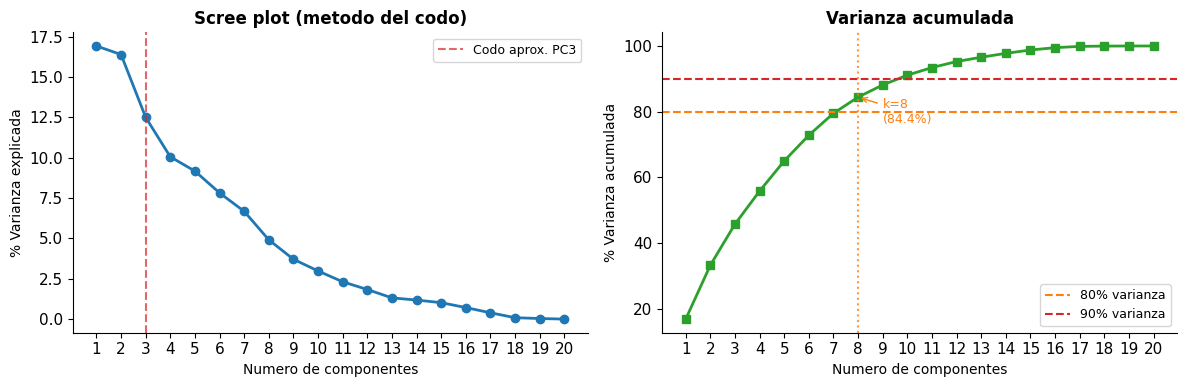

Criterio estandar (>=80% varianza acumulada): k = 8 componentes
Criterio del codo: k aprox. 3 componentes


In [43]:
# ─────────────────────────────────────────────
# 2) Scree plot + varianza acumulada
# ─────────────────────────────────────────────
n_show = min(20, n_components_all)
x_vals = np.arange(1, n_show + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Scree plot
ax = axes[0]
ax.plot(x_vals, explained_var[:n_show] * 100, 'o-', color='#1f77b4', linewidth=2)
ax.set_xlabel('Numero de componentes')
ax.set_ylabel('% Varianza explicada')
ax.set_title('Scree plot (metodo del codo)', fontweight='bold')
ax.set_xticks(x_vals)
diffs = np.diff(explained_var[:n_show])
elbow = int(np.argmax(np.abs(diffs)) + 2)
ax.axvline(x=elbow, color='#d62728', linestyle='--', alpha=0.7, label=f'Codo aprox. PC{elbow}')
ax.legend(fontsize=9)

# Varianza acumulada
ax2 = axes[1]
ax2.plot(x_vals, cumulative_var[:n_show] * 100, 's-', color='#2ca02c', linewidth=2)
ax2.axhline(y=80, color='#ff7f0e', linestyle='--', linewidth=1.5, label='80% varianza')
ax2.axhline(y=90, color='#d62728', linestyle='--', linewidth=1.5, label='90% varianza')
k80 = int(np.searchsorted(cumulative_var, 0.80)) + 1
ax2.axvline(x=k80, color='#ff7f0e', linestyle=':', alpha=0.8)
ax2.annotate(
    f'k={k80}\n({cumulative_var[k80-1]*100:.1f}%)',
    xy=(k80, cumulative_var[k80-1]*100),
    xytext=(k80 + 1, cumulative_var[k80-1]*100 - 8),
    fontsize=9, color='#ff7f0e',
    arrowprops=dict(arrowstyle='->', color='#ff7f0e')
)
ax2.set_xlabel('Numero de componentes')
ax2.set_ylabel('% Varianza acumulada')
ax2.set_title('Varianza acumulada', fontweight='bold')
ax2.set_xticks(x_vals)
ax2.legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f'Criterio estandar (>=80% varianza acumulada): k = {k80} componentes')
print(f'Criterio del codo: k aprox. {elbow} componentes')


### Interpretación: Scree plot y varianza acumulada

Los dos gráficos responden la misma pregunta: **¿con cuántos componentes me quedo?**

- **Scree plot (izquierda):** muestra la varianza capturada por cada PC individualmente. El "codo" indica el punto donde agregar un componente más deja de aportar significativamente. En este caso el codo cae en **k≈3**.

- **Varianza acumulada (derecha):** suma la varianza de los componentes progresivamente. El criterio estándar es retener los primeros k que acumulen al menos el 80% de la varianza total. Aquí se alcanza con **k=8** (84.4% acumulado).

Se elige **k=8** porque el objetivo es reducir dimensionalidad para modelado predictivo, no solo visualización. Con 8 componentes (de 22 originales) se retiene el 84.4% de la información, reduciendo la dimensionalidad un 64%.

In [44]:
# ─────────────────────────────────────────────
# 3) PCA reducido con k seleccionado
# ─────────────────────────────────────────────
K = k80   # criterio: varianza acumulada >= 80%

pca_k = PCA(n_components=K, random_state=42)
X_train_pca = pca_k.fit_transform(X_train_sel)  # fit en TRAIN
X_test_pca  = pca_k.transform(X_test_sel)        # solo transform en TEST

print(f'PCA con k = {K} componentes')
print(f'  Shape original  -> {X_train_sel.shape}')
print(f'  Shape reducido  -> {X_train_pca.shape}')
print(f'  Varianza total capturada: {pca_k.explained_variance_ratio_.sum()*100:.2f}%')
print()
pc_cols = [f'PC{i+1}' for i in range(K)]
print('Scores (primeras 5 filas):')
print(pd.DataFrame(X_train_pca[:5], columns=pc_cols).round(3).to_string(index=False))


PCA con k = 8 componentes
  Shape original  -> (308734, 22)
  Shape reducido  -> (308734, 8)
  Varianza total capturada: 84.44%

Scores (primeras 5 filas):
   PC1    PC2    PC3    PC4    PC5    PC6    PC7    PC8
 0.327 -1.587  0.644  0.279 -0.116 -0.757 -0.465 -0.969
 0.731 -0.532 -0.885 -0.898  0.466  0.006 -0.625  0.715
 0.442  0.546 -1.193 -2.183  0.893 -0.367  1.157 -0.009
 0.682 -1.316  0.279 -0.040  1.066  0.198 -1.435  0.520
-0.838 -0.420 -0.333  1.953 -0.367  1.395 -0.503  1.381


── Loadings (contribucion de cada feature a cada PC) ─────────
                      PC1    PC2    PC3    PC4    PC5    PC6    PC7    PC8
civilian_ratio     -0.246  0.007 -0.319  0.713  0.163  0.165  0.427  0.094
country_te          0.182 -0.008 -0.207  0.096 -0.013  0.026 -0.260 -0.190
date_prec           0.285  0.531  0.149  0.277  0.064 -0.209 -0.035 -0.010
dyad_freq           0.169 -0.268  0.064  0.162 -0.012 -0.164  0.126 -0.494
era_1989-99        -0.014  0.084 -0.139 -0.083 -0.006 -0.136  0.045  0.064
era_2000-09        -0.033  0.051 -0.105 -0.078 -0.007  0.009  0.034  0.092
era_2010-19         0.070 -0.119  0.016  0.116 -0.005 -0.055 -0.014 -0.443
era_2020-24        -0.024 -0.016  0.228  0.044  0.017  0.181 -0.064  0.287
event_clarity       0.398  0.451  0.215  0.208  0.078 -0.189 -0.023  0.031
latitude            0.381 -0.452  0.139  0.037  0.006 -0.386  0.374  0.388
longitude           0.474 -0.188 -0.463  0.150 -0.029  0.244 -0.362  0.177
month_sin          -0.039  0.064  0.0

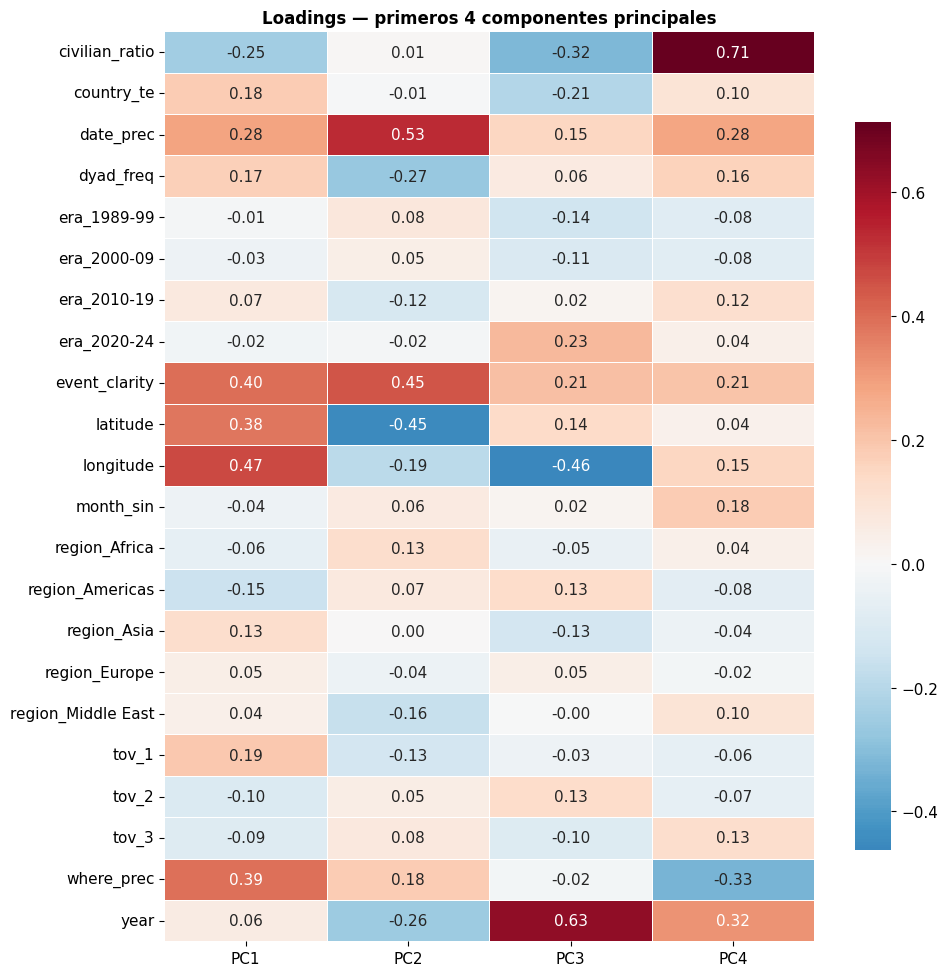

In [45]:
# ─────────────────────────────────────────────
# 4) Analisis de loadings (autovectores)
#    Los loadings indican cuanto contribuye cada
#    feature original a cada componente principal.
# ─────────────────────────────────────────────
loadings_df = pd.DataFrame(
    pca_k.components_.T,
    index=SELECTED_FEATS,
    columns=pc_cols
)

print('── Loadings (contribucion de cada feature a cada PC) ─────────')
print(loadings_df.round(3).to_string())
print()
print('── Top 5 features por modulo en PC1 ─────────────────────────')
print(loadings_df['PC1'].abs().sort_values(ascending=False).head(5).round(3))
print()
print('── Top 5 features por modulo en PC2 ─────────────────────────')
print(loadings_df['PC2'].abs().sort_values(ascending=False).head(5).round(3))

# Heatmap
n_show_pc = min(4, K)
fig, ax = plt.subplots(figsize=(n_show_pc * 2 + 2, max(6, len(SELECTED_FEATS) * 0.45)))
sns.heatmap(
    loadings_df.iloc[:, :n_show_pc],
    cmap='RdBu_r', center=0, annot=True, fmt='.2f',
    linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8}
)
ax.set_title(f'Loadings — primeros {n_show_pc} componentes principales', fontweight='bold')
plt.tight_layout()
plt.show()


### Interpretación: Loadings

Los loadings indican **cuánto contribuye cada feature original a cada componente principal**.
Un valor alto en módulo (cercano a 1 o -1) significa que esa feature "pesa" mucho en ese PC.

**PC1 — Calidad de registro del evento**
Las features con mayor peso son `longitude`, `event_clarity`, `where_prec` y `latitude`.
PC1 captura la **precisión** tanto espacial (`longitud`/`latitud` → eventos bien geolocalizados) como descriptiva (`event_clarity`, `where_prec` → registro bien documentado).

**PC2 — Dimensión temporal e identidad del conflicto**
Dominado por `date_prec`, `latitude`, `event_clarity` y `dyad_freq`.
PC2 combina la **precisión temporal del evento** con la frecuencia de la díada (el par de actores enfrentados), capturando la dimensión cronológica e identitaria del conflicto.

**PC3 — Evolución temporal y geografía**
`year` (0.63) y `longitude` (-0.46) son los loadings dominantes.
PC3 captura la **tendencia temporal** del dataset (1989–2024) en combinación con la ubicación geográfica longitudinal.

**PC4 - Letalidad civil y precisión geográfica espacial**
Las features con mayor perso son `civilian_ratio`, `year`, `date_prec`, `where_prec` y `longitude`.
PC4 está dominado por `civilian_ratio`, capturando la **proporción de víctimas civiles** del evento.

> **Nota general:** ningún PC está dominado por una sola variable, lo que refleja que las features del dataset están correlacionadas entre sí. Esto es precisamente lo que PCA aprovecha para comprimir la información.

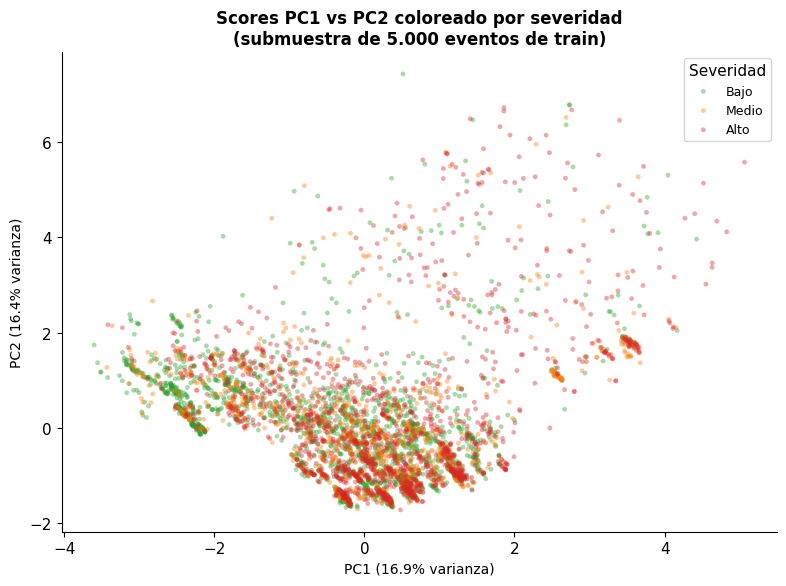

In [46]:
# ─────────────────────────────────────────────
# 5) Visualizacion de scores: PC1 vs PC2
#    Permite ver la separacion entre clases de severidad
# ─────────────────────────────────────────────
np.random.seed(42)
n_sample = min(5000, len(X_train_pca))
sample_idx = np.random.choice(len(X_train_pca), size=n_sample, replace=False)

scores_sample = X_train_pca[sample_idx, :2]
labels_sample = y_train.iloc[sample_idx].values

colors_map = {0: '#2ca02c', 1: '#ff7f0e', 2: '#d62728'}
label_names = {0: 'Bajo', 1: 'Medio', 2: 'Alto'}

fig, ax = plt.subplots(figsize=(8, 6))
for cls in [0, 1, 2]:
    mask = labels_sample == cls
    ax.scatter(scores_sample[mask, 0], scores_sample[mask, 1],
               c=colors_map[cls], label=label_names[cls],
               alpha=0.4, s=12, edgecolors='none')

ax.set_xlabel(f'PC1 ({pca_k.explained_variance_ratio_[0]*100:.1f}% varianza)')
ax.set_ylabel(f'PC2 ({pca_k.explained_variance_ratio_[1]*100:.1f}% varianza)')
ax.set_title('Scores PC1 vs PC2 coloreado por severidad\n(submuestra de 5.000 eventos de train)', fontweight='bold')
ax.legend(title='Severidad', fontsize=9)
plt.tight_layout()
plt.show()


### Interpretación: Scatter PC1 vs PC2

Cada punto es un evento de violencia proyectado sobre los dos primeros componentes principales.
El color indica la clase de severidad: **verde = baja, naranja = media, rojo = alta**.

Lo que se observa es una **superposición considerable entre las tres clases**, lo que indica que PC1 y PC2 solos (que juntos explican el 33% de la varianza) no logran separar limpiamente los niveles de severidad. Esto es esperable: la severidad depende de información distribuida en múltiples componentes, no solo en los dos primeros.

> Esto justifica la elección de **k=8** para el modelado: con solo 2 componentes se pierde demasiada información discriminativa. El scatter sirve como visualización exploratoria, no como criterio de selección de k.

### Evaluacion: ventajas y desventajas de la reduccion

| | Seleccion de features (filtros) | Extraccion con PCA |
|---|---|---|
| **Ventaja principal** | Conserva interpretabilidad: se sabe que variable importa | Maximiza la varianza retenida con la menor cantidad de dimensiones |
| **Reduccion** | Elimina features irrelevantes o redundantes | Comprime en nuevos ejes ortogonales (combinacion lineal) |
| **Interpretabilidad** | Alta (features originales) | Baja (los PCs combinan linealmente todas las features) |
| **Asuncion** | Independencia de cada feature con el target | Relaciones **lineales** entre features |
| **Perdida de informacion** | Descarta features completas | Controlada: elegimos k para retener >= 80% de varianza |
| **Cuando usar** | Cuando la interpretabilidad es critica | Cuando se necesita compresion y el modelo no requiere interpretabilidad de features |

**En este dataset:**
- La **seleccion por filtros** es adecuada para el modelo final: `country_te`, `latitude`, `longitude` y `civilian_ratio` tienen interpretacion directa y son los drivers del target.
- **PCA** es util para visualizar la separacion entre clases en 2D y para modelos donde la multicolinealidad entre variables geograficas y temporales puede ser problematica.


In [47]:
# ─────────────────────────────────────────────
# Resumen final: comparacion de dimensiones
# ─────────────────────────────────────────────
original_dims    = X_train_fe.shape[1]
selected_dims    = X_train_sel.shape[1]
pca_dims         = X_train_pca.shape[1]
pca_var_retained = pca_k.explained_variance_ratio_.sum()

print('=' * 52)
print('  RESUMEN REDUCCION DE DIMENSIONALIDAD')
print('=' * 52)
print(f'  Dims originales (Feature Eng.)  : {original_dims:>4}')
print(f'  Dims tras filtros               : {selected_dims:>4}  ({selected_dims/original_dims*100:.0f}% del original)')
print(f'  Dims tras PCA (k={K})           : {pca_dims:>4}  ({pca_var_retained*100:.1f}% varianza retenida)')
print()
print('  Matrices disponibles para el modelo:')
print(f'    X_train_fe / X_test_fe    -> features completas     ({original_dims} cols)')
print(f'    X_train_sel / X_test_sel  -> seleccion por filtros  ({selected_dims} cols)')
print(f'    X_train_pca / X_test_pca  -> PCA k={K}              ({pca_dims} cols)')
print('=' * 52)


  RESUMEN REDUCCION DE DIMENSIONALIDAD
  Dims originales (Feature Eng.)  :   23
  Dims tras filtros               :   22  (96% del original)
  Dims tras PCA (k=8)           :    8  (84.4% varianza retenida)

  Matrices disponibles para el modelo:
    X_train_fe / X_test_fe    -> features completas     (23 cols)
    X_train_sel / X_test_sel  -> seleccion por filtros  (22 cols)
    X_train_pca / X_test_pca  -> PCA k=8              (8 cols)


---


# Trabajo Práctico: Aprendizaje de Máquina

#### A partir de esta sección, se realiza el desarrollo del trabajo poniendo el foco en el modelo de Machine Learning que resuelve el problema planteado anteriormente, detallado como "Predicción de severidad de eventos". Consiste en una clasificación supervisada multicalse, cuyo objetivo es predecir la severidad de un evento de violencia organizada a partir de sus características contextuales. La variable target es $severity$, construida a partir de $best$ mediante discretización por percentiles. Esto garantiza clases aproximadamente balanceadas y constituye un caso de target engineering.

| Clase | Criterio | Etiqueta |
|---|---|---|
| 0 | `best` < percentil 33 | Bajo |
| 1 | percentil 33 ≤ `best` < percentil 66 | Medio |
| 2 | `best` ≥ percentil 66 | Alto |

## Baseline heurístico

Antes de entrenar cualquier modelo se establece un **baseline heurístico**: se elige la predicción más simple posible que no requiere entrenamiento, ajuste de hiperparámetros ni acceso a los features.

**Regla simple:** asignar a cada evento la clase mayoritaria observada en el conjunto de entrenamiento.

Del análisis de balance de clases sabemos que la distribución en train es:
 
| Clase | % en train |
|---|---|
| Bajo (0) | 44.9 % |
| Medio (1) | 24.8 % |
| Alto (2) | 30.3 % |
 
La clase mayoritaria es **Bajo (0)**. El baseline predice `0` para todos los eventos del test set.

La regla de la clase mayoritaria (*Most Frequent Class*) es el piso mínimo que cualquier clasificador debe superar: si el modelo no mejora respecto a "predecir siempre lo mismo", no aporta valor. Es preferible a una regla aleatoria porque no introduce varianza, y a una regresión logística porque no requiere entrenamiento ni supone relaciones lineales entre features y target.

════════════════════════════════════════════════════
  BASELINE HEURÍSTICO — Clase Mayoritaria
════════════════════════════════════════════════════
  Clase predicha siempre : Bajo (0)
  Accuracy               : 0.4487  (44.87 %)
  Macro F1               : 0.2065

  Reporte por clase:
              precision    recall  f1-score   support

        Bajo       0.45      1.00      0.62     34634
       Medio       0.00      0.00      0.00     19127
        Alto       0.00      0.00      0.00     23423

    accuracy                           0.45     77184
   macro avg       0.15      0.33      0.21     77184
weighted avg       0.20      0.45      0.28     77184



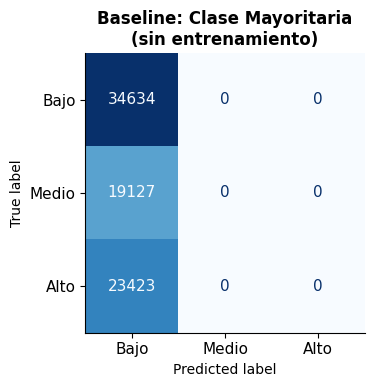

In [48]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score, accuracy_score)

dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train_sel, y_train)        # solo observa la distribución de y_train
y_pred_baseline = dummy.predict(X_test_sel)
 
acc_bl  = accuracy_score(y_test, y_pred_baseline)
f1_bl   = f1_score(y_test, y_pred_baseline, average='macro', zero_division=0)
 
print('═' * 52)
print('  BASELINE HEURÍSTICO — Clase Mayoritaria')
print('═' * 52)
print(f'  Clase predicha siempre : Bajo (0)')
print(f'  Accuracy               : {acc_bl:.4f}  ({acc_bl*100:.2f} %)')
print(f'  Macro F1               : {f1_bl:.4f}')
print()
print('  Reporte por clase:')
print(classification_report(y_test, y_pred_baseline,
                             target_names=['Bajo','Medio','Alto'],
                             zero_division=0))
 
# Visualización — matriz de confusión del baseline
fig, ax = plt.subplots(figsize=(5, 4))
cm_bl = confusion_matrix(y_test, y_pred_baseline)
disp  = ConfusionMatrixDisplay(cm_bl, display_labels=['Bajo','Medio','Alto'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Baseline: Clase Mayoritaria\n(sin entrenamiento)', fontweight='bold')
plt.tight_layout()
plt.show()

`Interpretación: el baseline tiene un Accuracy de 44,87%, el cual coincide con la proporción de la clase mayoritaria. A su vez, posee un Macro F1 de 0,2, ya que no predice nunca las clases Medio y Alto. Esto sienta las bases de nuestro problema de ML, donde cualquier modelo entrenado debe superar ambos valores para considerarse útil.`

## Árbol de Decisión

El **Árbol de Decisión** es el primer modelo supervisado que entrenamos. A diferencia del baseline heurístico, aprende reglas de decisión a partir de los features y puede distinguir entre las tres clases de severidad.

Se elige como punto de partida porque:
- Es interpretable: permite visualizar las reglas aprendidas.
- Sirve como componente base de los métodos de ensamble que se implementarán a continuación (Random Forest y XGBoost).
- El contraste entre su rendimiento y el del baseline cuantifica cuánto aporta el aprendizaje supervisado.

In [49]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score, accuracy_score
)

# ── Entrenamiento ─────────────────────────────────────────────────────────
dt_default = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42
)
dt_default.fit(X_train_sel, y_train)

# ── Predicción ────────────────────────────────────────────────────────────
y_pred_dt = dt_default.predict(X_test_sel)

# ── Métricas ──────────────────────────────────────────────────────────────
acc_dt  = accuracy_score(y_test, y_pred_dt)
f1_dt   = f1_score(y_test, y_pred_dt, average='macro', zero_division=0)

print('=' * 52)
print('  ÁRBOL DE DECISIÓN — Hiperparámetros por defecto')
print('=' * 52)
print(f'  Profundidad máxima alcanzada : {dt_default.get_depth()}')
print(f'  Accuracy                     : {acc_dt:.4f}  ({acc_dt*100:.2f} %)')
print(f'  Macro F1                     : {f1_dt:.4f}')
print()
print('  Reporte por clase:')
print(classification_report(y_test, y_pred_dt,
                             target_names=['Bajo','Medio','Alto'],
                             zero_division=0))


  ÁRBOL DE DECISIÓN — Hiperparámetros por defecto
  Profundidad máxima alcanzada : 52
  Accuracy                     : 0.5352  (53.52 %)
  Macro F1                     : 0.5159

  Reporte por clase:
              precision    recall  f1-score   support

        Bajo       0.64      0.60      0.62     34634
       Medio       0.35      0.39      0.37     19127
        Alto       0.56      0.56      0.56     23423

    accuracy                           0.54     77184
   macro avg       0.52      0.52      0.52     77184
weighted avg       0.54      0.54      0.54     77184



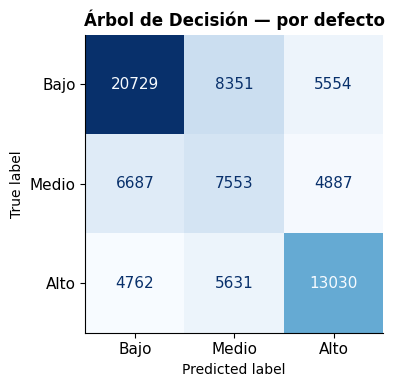

In [50]:
# ── Matriz de confusión — modelo por defecto ──────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp  = ConfusionMatrixDisplay(cm_dt, display_labels=['Bajo','Medio','Alto'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Árbol de Decisión — por defecto', fontweight='bold')
plt.tight_layout()
plt.show()


### Interpretación — modelo por defecto

El árbol sin restricciones crece hasta su máxima profundidad, memorizando el conjunto de entrenamiento (**sobreajuste / overfitting**). Esto se refleja en:

- Un Accuracy y Macro F1 en test generalmente inferiores a lo esperado si el árbol fuera más general.
- La matriz de confusión muestra errores distribuidos entre las tres clases, a diferencia del baseline que solo predecía *Bajo*.

> La comparación con el baseline confirma que el modelo aprende patrones reales, pero la falta de regularización limita su capacidad de generalización. La siguiente etapa busca corregir esto mediante la búsqueda de hiperparámetros.

### Búsqueda de hiperparámetros

Se utiliza **`GridSearchCV`** con validación cruzada estratificada (5 folds) para encontrar la combinación óptima de hiperparámetros que maximice el **Macro F1** en validación. Los parámetros explorados son:

| Parámetro | Descripción | Valores explorados |
|---|---|---|
| `max_depth` | Profundidad máxima del árbol | 3, 5, 8, 12, `None` |
| `min_samples_split` | Mínimo de muestras para dividir un nodo | 2, 50, 200 |
| `min_samples_leaf` | Mínimo de muestras en una hoja | 1, 20, 100 |
| `criterion` | Función de impureza | `gini`, `entropy` |

> **Nota:** el fit se realiza únicamente sobre `X_train_sel` / `y_train`. El conjunto de test no participa en ninguna etapa de la búsqueda (sin data leakage).

In [51]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import warnings
warnings.filterwarnings('ignore')

param_grid_dt = {
    'max_depth'        : [3, 5, 8, 12, None],
    'min_samples_split': [2, 50, 200],
    'min_samples_leaf' : [1, 20, 100],
    'criterion'        : ['gini', 'entropy'],
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gs_dt = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    param_grid_dt,
    scoring='f1_macro',
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1
)
gs_dt.fit(X_train_sel, y_train)

print('Mejores hiperparámetros encontrados:')
for k, v in gs_dt.best_params_.items():
    print(f'  {k:<22}: {v}')
print(f'\n  Macro F1 en CV (val): {gs_dt.best_score_:.4f}')


Fitting 5 folds for each of 90 candidates, totalling 450 fits
Mejores hiperparámetros encontrados:
  criterion             : entropy
  max_depth             : None
  min_samples_leaf      : 1
  min_samples_split     : 200

  Macro F1 en CV (val): 0.5436


### Modelo optimizado — evaluación final

Se evalúa el mejor estimador encontrado por `GridSearchCV` sobre el conjunto de test para obtener las métricas definitivas del Árbol de Decisión.

In [52]:
# ── Predicción con el modelo optimizado ───────────────────────────────────
best_dt       = gs_dt.best_estimator_
y_pred_dt_opt = best_dt.predict(X_test_sel)

acc_dt_opt = accuracy_score(y_test, y_pred_dt_opt)
f1_dt_opt  = f1_score(y_test, y_pred_dt_opt, average='macro', zero_division=0)

print('=' * 52)
print('  ÁRBOL DE DECISIÓN — Optimizado')
print('=' * 52)
print(f'  Profundidad máxima alcanzada : {best_dt.get_depth()}')
print(f'  Accuracy                     : {acc_dt_opt:.4f}  ({acc_dt_opt*100:.2f} %)')
print(f'  Macro F1                     : {f1_dt_opt:.4f}')
print()
print('  Reporte por clase:')
print(classification_report(y_test, y_pred_dt_opt,
                             target_names=['Bajo','Medio','Alto'],
                             zero_division=0))


  ÁRBOL DE DECISIÓN — Optimizado
  Profundidad máxima alcanzada : 35
  Accuracy                     : 0.5676  (56.76 %)
  Macro F1                     : 0.5488

  Reporte por clase:
              precision    recall  f1-score   support

        Bajo       0.69      0.61      0.65     34634
       Medio       0.38      0.42      0.40     19127
        Alto       0.58      0.63      0.60     23423

    accuracy                           0.57     77184
   macro avg       0.55      0.55      0.55     77184
weighted avg       0.58      0.57      0.57     77184



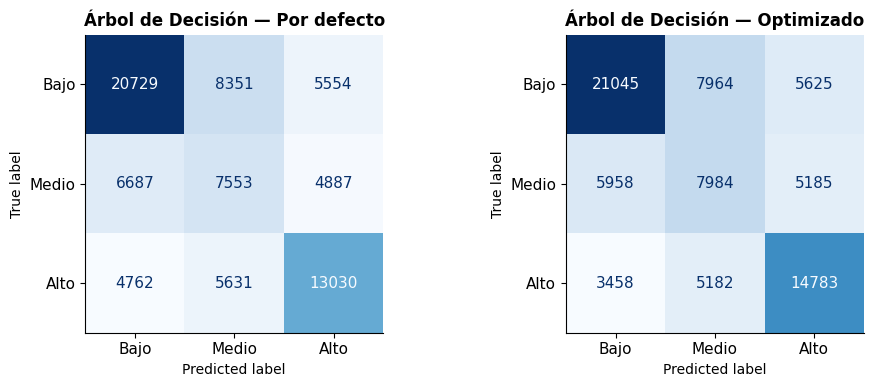

In [53]:
# ── Comparación: por defecto vs optimizado ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, cm, title in zip(
    axes,
    [cm_dt, confusion_matrix(y_test, y_pred_dt_opt)],
    ['Por defecto', 'Optimizado']
):
    disp = ConfusionMatrixDisplay(cm, display_labels=['Bajo','Medio','Alto'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Árbol de Decisión — {title}', fontweight='bold')

plt.tight_layout()
plt.show()


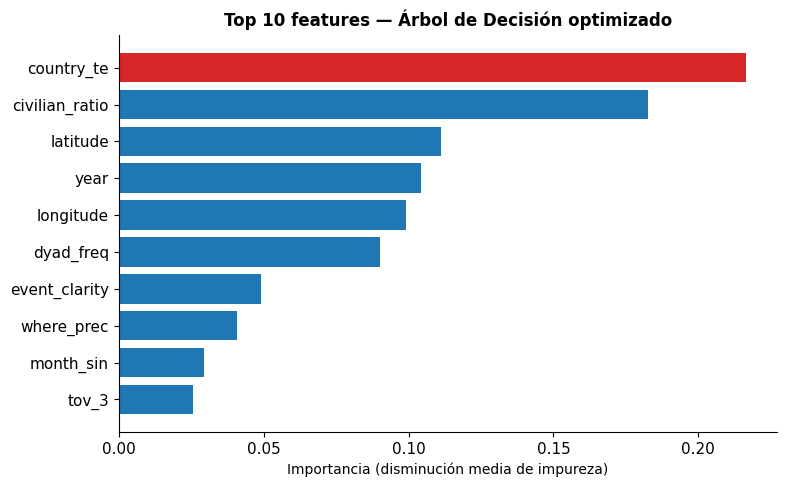


Top 5 features por importancia:
  country_te                     0.2163
  civilian_ratio                 0.1826
  latitude                       0.1113
  year                           0.1044
  longitude                      0.0992


In [54]:
# ── Importancia de features ───────────────────────────────────────────────
feat_imp = pd.Series(
    best_dt.feature_importances_,
    index=SELECTED_FEATS
).sort_values(ascending=True)

# Mostrar solo las 10 más importantes
top10 = feat_imp.tail(10)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#d62728' if v == top10.max() else '#1f77b4' for v in top10.values]
ax.barh(top10.index, top10.values, color=colors)
ax.set_xlabel('Importancia (disminución media de impureza)')
ax.set_title('Top 10 features — Árbol de Decisión optimizado', fontweight='bold')
plt.tight_layout()
plt.show()

print('\nTop 5 features por importancia:')
for feat, val in feat_imp.tail(5).sort_values(ascending=False).items():
    print(f'  {feat:<30} {val:.4f}')


### Interpretación — modelo optimizado

**Hiperparámetros seleccionados por GridSearchCV:**
Los mejores parámetros encontrados son `max_depth=None`, `min_samples_split=200`, `min_samples_leaf=1`. Es importante notar que la regularización **no proviene de limitar la profundidad** (`max_depth=None` permite que el árbol crezca libremente), sino de requerir al menos 200 muestras para realizar una división (`min_samples_split=200`). Esto evita que el árbol cree ramas basadas en grupos muy pequeños de datos, reduciendo el sobreajuste sin imponer un techo de profundidad explícito.

**Matrices de confusión:** el modelo optimizado mejora respecto al árbol por defecto: Accuracy de 53.58% → 56.76%, Macro F1 de 0.52 → 0.55. La clase *Medio* sigue siendo la más difícil (F1 = 0.40), lo cual es esperable dada la superposición observada en el scatter PCA.

**Feature Importance:** el árbol mide la importancia de cada variable como la reducción media de impureza (Gini o entropía) que aporta en los nodos donde se utiliza. Las features con mayor importancia son consistentes con los resultados del filtro ANOVA de la etapa de selección, lo que valida la coherencia del pipeline completo.

**Comparación con el baseline:**

| Modelo | Accuracy | Macro F1 |
|---|---|---|
| Baseline (clase mayoritaria) | 44.87 % | 0.2065 |
| Árbol de Decisión (por defecto) | 53.58 % | 0.5164 |
| Árbol de Decisión (optimizado) | 56.76 % | 0.5488 |

El modelo optimizado supera al baseline en +11.89 pp de Accuracy y +0.34 de Macro F1, confirmando que el árbol aprende patrones reales. La mejora más relevante es la capacidad de identificar eventos de severidad *Alta* y *Media*, clases que el baseline ignoraba por completo.

> **Nota metodológica — target encoding en CV:** la feature `country_te` fue construida con target encoding ajustado sobre el conjunto de entrenamiento completo **antes** de ejecutar `GridSearchCV`. Esto introduce una forma leve de leakage dentro del CV: los folds de validación contienen valores de `country_te` calculados con sus propias etiquetas, lo que puede hacer que los scores de CV sean levemente optimistas. Sin embargo, el leakage **no afecta al conjunto de test** (que nunca participó en el encoding), por lo que las métricas finales reportadas sobre test son válidas. Una solución más rigurosa sería incorporar el encoder dentro de un `Pipeline` de scikit-learn para que se reajuste en cada fold.

La limitación principal del árbol individual es su **alta varianza**: pequeñas perturbaciones en los datos pueden cambiar significativamente su estructura. Este problema se aborda en el siguiente modelo: **Random Forest**, que combina cientos de árboles entrenados sobre submuestras distintas para reducir esa varianza.


### Curva ROC — Árbol de Decisión optimizado

Para problemas multiclase se utiliza la estrategia **One-vs-Rest (OvR)**: se calcula una curva ROC por clase, tratando cada clase como positiva frente al resto. El área bajo la curva (AUC) mide la capacidad del modelo para separar cada clase del resto: AUC = 1.0 es separación perfecta, AUC = 0.5 equivale a predicción aleatoria.


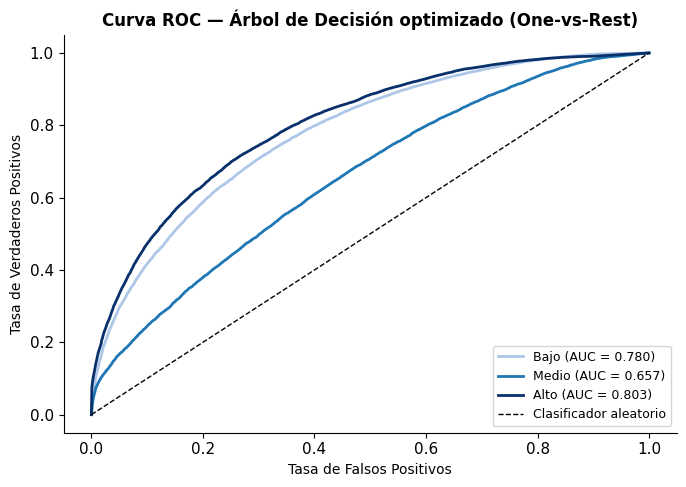

In [55]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# ── Binarizar el target para OvR ──────────────────────────────────────────
classes    = [0, 1, 2]
y_test_bin = label_binarize(y_test, classes=classes)

# ── Probabilidades del modelo optimizado ──────────────────────────────────
y_prob_dt = best_dt.predict_proba(X_test_sel)

# ── Curvas ROC por clase ───────────────────────────────────────────────────
class_names = ['Bajo', 'Medio', 'Alto']
colors = ['#aec7e8', '#1f77b4', '#08306b']

fig, ax = plt.subplots(figsize=(7, 5))

for i, (name, color) in enumerate(zip(class_names, colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_dt[:, i])
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{name} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Clasificador aleatorio')
ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Tasa de Verdaderos Positivos')
ax.set_title('Curva ROC — Árbol de Decisión optimizado (One-vs-Rest)', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()


### Interpretación — Curva ROC

La curva ROC muestra el trade-off entre la **Tasa de Verdaderos Positivos** (sensibilidad) y la **Tasa de Falsos Positivos** para cada umbral de decisión.

- **Clase Bajo** — suele tener el AUC más alto porque es la clase mayoritaria y la más fácil de separar del resto.
- **Clase Medio** — esperable que tenga el AUC más bajo, consistente con su menor F1 en el reporte de clasificación. La clase Medio se superpone con las otras dos en el espacio de features.
- **Clase Alto** — AUC intermedio, el modelo la distingue mejor que Medio pero peor que Bajo.

> Un AUC > 0.70 para todas las clases indica que el árbol tiene capacidad discriminativa real más allá del azar, aunque con margen de mejora. La curva ROC se volverá a calcular para Random Forest y XGBoost, permitiendo una **comparación directa** entre los tres modelos en la sección de conclusiones.


## Random Forest

El **Random Forest** es un método de ensamble de tipo **Bagging** (Bootstrap Aggregating) que combina múltiples árboles de decisión entrenados sobre submuestras aleatorias del conjunto de entrenamiento.

Respecto al árbol individual, introduce dos fuentes adicionales de aleatoriedad:

1. **Bootstrap:** cada árbol se entrena sobre una muestra con reposición del conjunto de train.
2. **Random subspace:** en cada división del árbol, solo se evalúa un subconjunto aleatorio de features (por defecto √p, donde p es el número total de features). Esto **descorrelaciona** los árboles entre sí, evitando que todos ellos dependan del mismo predictor fuerte.

La predicción final se obtiene por **votación mayoritaria** entre todos los árboles. Al promediar modelos con alta varianza y bajo sesgo, el ensamble reduce la varianza sin aumentar el sesgo, que es exactamente la limitación que mostró el árbol individual.


### Entrenamiento con hiperparámetros por defecto

Se entrena un Random Forest con 200 árboles como punto de partida. Se usa `class_weight='balanced'` por las mismas razones que en el árbol individual, y `n_jobs=-1` para aprovechar todos los núcleos disponibles dado el tamaño del dataset (308k filas).

In [56]:
from sklearn.ensemble import RandomForestClassifier

# ── Entrenamiento por defecto ──────────────────────────────────────────────
rf_default = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_default.fit(X_train_sel, y_train)

# ── Verificación del orden de clases ──────────────────────────────────────
print(f'Orden de clases del modelo: {rf_default.classes_}')
print(f'  0 = Bajo | 1 = Medio | 2 = Alto')
print(f'  target_names en classification_report sigue este orden.')

# ── Predicción y métricas train vs test ───────────────────────────────────
y_pred_rf       = rf_default.predict(X_test_sel)
y_pred_rf_train = rf_default.predict(X_train_sel)

acc_rf        = accuracy_score(y_test, y_pred_rf)
f1_rf         = f1_score(y_test, y_pred_rf, average='macro', zero_division=0)
acc_rf_train  = accuracy_score(y_train, y_pred_rf_train)
f1_rf_train   = f1_score(y_train, y_pred_rf_train, average='macro', zero_division=0)

print('=' * 52)
print('  RANDOM FOREST — Hiperparámetros por defecto')
print('=' * 52)
print(f'  Arboles          : {rf_default.n_estimators}')
print(f'  Features por nodo: {rf_default.max_features} (sqrt de {X_train_sel.shape[1]})')
print()
print(f'  {"Conjunto":<12} {"Accuracy":>10} {"Macro F1":>10}')
print(f'  {"-"*34}')
print(f'  {"Train":<12} {acc_rf_train:>10.4f} {f1_rf_train:>10.4f}')
print(f'  {"Test":<12} {acc_rf:>10.4f} {f1_rf:>10.4f}')
print(f'  {"Gap":<12} {acc_rf_train - acc_rf:>+10.4f} {f1_rf_train - f1_rf:>+10.4f}')
print()
print('  Reporte por clase (test):')
print(classification_report(y_test, y_pred_rf,
                             target_names=['Bajo','Medio','Alto'],
                             zero_division=0))


Orden de clases del modelo: [0 1 2]
  0 = Bajo | 1 = Medio | 2 = Alto
  target_names en classification_report sigue este orden.
  RANDOM FOREST — Hiperparámetros por defecto
  Arboles          : 200
  Features por nodo: sqrt (sqrt de 22)

  Conjunto       Accuracy   Macro F1
  ----------------------------------
  Train            0.8713     0.8647
  Test             0.5777     0.5451
  Gap             +0.2936    +0.3196

  Reporte por clase (test):
              precision    recall  f1-score   support

        Bajo       0.66      0.68      0.67     34634
       Medio       0.38      0.34      0.36     19127
        Alto       0.59      0.62      0.61     23423

    accuracy                           0.58     77184
   macro avg       0.54      0.55      0.55     77184
weighted avg       0.57      0.58      0.57     77184



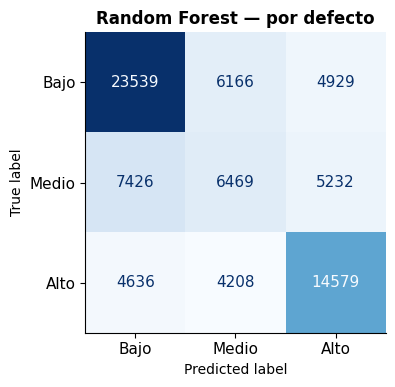

In [57]:
# ── Matriz de confusión — Random Forest por defecto ──────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=['Bajo','Medio','Alto']).plot(
    ax=ax, cmap='Blues', colorbar=False
)
ax.set_title('Random Forest — por defecto', fontweight='bold')
plt.tight_layout()
plt.show()


### Búsqueda de hiperparámetros

Dado el costo computacional de Random Forest sobre 308k filas, se usa **`RandomizedSearchCV`** en lugar de `GridSearchCV`. Este método muestrea aleatoriamente combinaciones del espacio de búsqueda, lo que permite explorar un rango más amplio de hiperparámetros con menor costo.

| Parámetro | Descripción | Valores explorados |
|---|---|---|
| `n_estimators` | Número de árboles en el bosque | 100, 200, 300 |
| `max_depth` | Profundidad máxima de cada árbol | 10, 20, 30, `None` |
| `min_samples_split` | Mínimo de muestras para dividir un nodo | 2, 50, 200 |
| `min_samples_leaf` | Mínimo de muestras en una hoja | 1, 10, 50 |
| `max_features` | Features evaluadas por nodo | `sqrt`, `log2` |

> Se fija `n_iter=20` para limitar el tiempo de entrenamiento. El ajuste se realiza únicamente sobre `X_train_sel` / `y_train` (sin data leakage del test set).

In [58]:
from sklearn.model_selection import RandomizedSearchCV

param_dist_rf = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [10, 20, 30, None],
    'min_samples_split': [2, 50, 200],
    'min_samples_leaf' : [1, 10, 50],
    'max_features'     : ['sqrt', 'log2'],
}

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rs_rf = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_distributions=param_dist_rf,
    n_iter=20,
    scoring='f1_macro',
    cv=cv_strategy,
    random_state=42,
    n_jobs=-1,
    verbose=1
)
rs_rf.fit(X_train_sel, y_train)

print('Mejores hiperparámetros encontrados:')
for k, v in rs_rf.best_params_.items():
    print(f'  {k:<22}: {v}')
print(f'\n  Macro F1 en CV (val): {rs_rf.best_score_:.4f}')


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Mejores hiperparámetros encontrados:
  n_estimators          : 200
  min_samples_split     : 50
  min_samples_leaf      : 1
  max_features          : log2
  max_depth             : 30

  Macro F1 en CV (val): 0.5604


### Modelo optimizado — evaluación final

Se evalúa el mejor estimador encontrado por `RandomizedSearchCV` sobre el conjunto de test.

In [59]:
# ── Predicción con el modelo optimizado ───────────────────────────────────
best_rf       = rs_rf.best_estimator_
y_pred_rf_opt = best_rf.predict(X_test_sel)

acc_rf_opt = accuracy_score(y_test, y_pred_rf_opt)
f1_rf_opt  = f1_score(y_test, y_pred_rf_opt, average='macro', zero_division=0)

print('=' * 52)
print('  RANDOM FOREST — Optimizado')
print('=' * 52)
print(f'  Accuracy : {acc_rf_opt:.4f}  ({acc_rf_opt*100:.2f} %)')
print(f'  Macro F1 : {f1_rf_opt:.4f}')
print()
print('  Reporte por clase:')
print(classification_report(y_test, y_pred_rf_opt,
                             target_names=['Bajo','Medio','Alto'],
                             zero_division=0))


  RANDOM FOREST — Optimizado
  Accuracy : 0.5923  (59.23 %)
  Macro F1 : 0.5661

  Reporte por clase:
              precision    recall  f1-score   support

        Bajo       0.70      0.65      0.68     34634
       Medio       0.40      0.38      0.39     19127
        Alto       0.59      0.68      0.63     23423

    accuracy                           0.59     77184
   macro avg       0.56      0.57      0.57     77184
weighted avg       0.59      0.59      0.59     77184



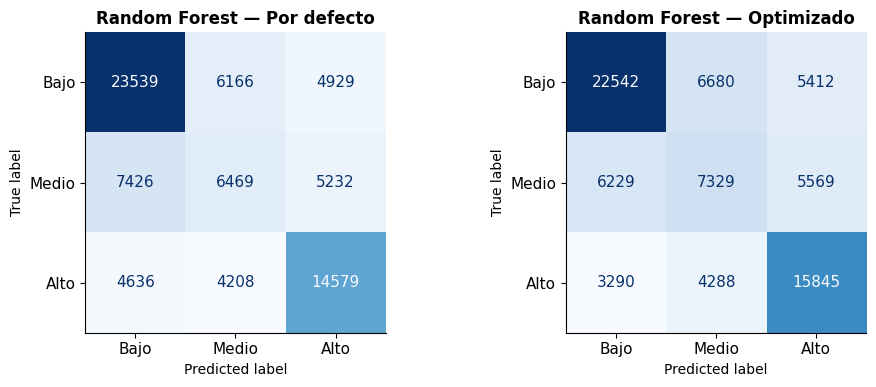

In [60]:
# ── Comparación: por defecto vs optimizado ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, cm, title in zip(
    axes,
    [cm_rf, confusion_matrix(y_test, y_pred_rf_opt)],
    ['Por defecto', 'Optimizado']
):
    ConfusionMatrixDisplay(cm, display_labels=['Bajo','Medio','Alto']).plot(
        ax=ax, cmap='Blues', colorbar=False
    )
    ax.set_title(f'Random Forest — {title}', fontweight='bold')

plt.tight_layout()
plt.show()


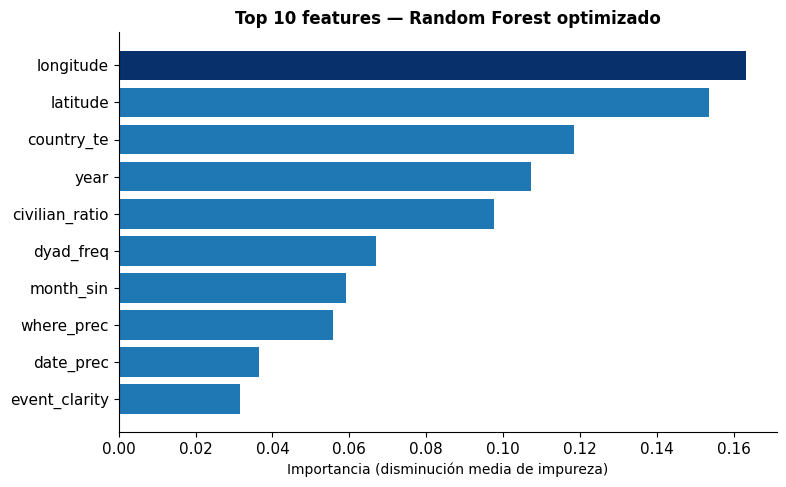

Top 5 features por importancia:
  longitude                      0.1631
  latitude                       0.1537
  country_te                     0.1185
  year                           0.1073
  civilian_ratio                 0.0977


In [61]:
# ── Importancia de features — Random Forest optimizado ───────────────────
feat_imp_rf = pd.Series(
    best_rf.feature_importances_,
    index=SELECTED_FEATS
).sort_values(ascending=True)

top10_rf = feat_imp_rf.tail(10)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#08306b' if v == top10_rf.max() else '#1f77b4' for v in top10_rf.values]
ax.barh(top10_rf.index, top10_rf.values, color=colors)
ax.set_xlabel('Importancia (disminución media de impureza)')
ax.set_title('Top 10 features — Random Forest optimizado', fontweight='bold')
plt.tight_layout()
plt.show()

print('Top 5 features por importancia:')
for feat, val in feat_imp_rf.tail(5).sort_values(ascending=False).items():
    print(f'  {feat:<30} {val:.4f}')


### Curva ROC — Random Forest optimizado

Se calcula la curva ROC con estrategia One-vs-Rest para comparar directamente con el árbol de decisión optimizado.

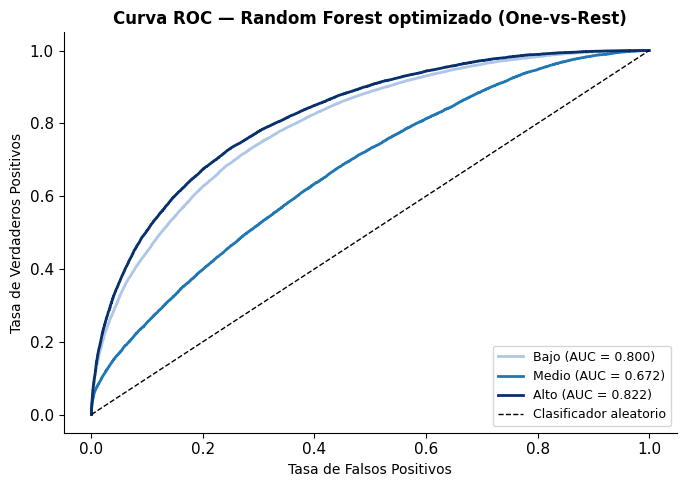

In [62]:
# ── Curva ROC — Random Forest optimizado ─────────────────────────────────
y_prob_rf = best_rf.predict_proba(X_test_sel)

fig, ax = plt.subplots(figsize=(7, 5))

for i, (name, color) in enumerate(zip(class_names, ['#aec7e8', '#1f77b4', '#08306b'])):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_rf[:, i])
    roc_auc     = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{name} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Clasificador aleatorio')
ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Tasa de Verdaderos Positivos')
ax.set_title('Curva ROC — Random Forest optimizado (One-vs-Rest)', fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()


### Interpretación — Random Forest

**Reducción del sobreajuste:** a diferencia del árbol individual (gap train-test de ~0.46 en Macro F1), el Random Forest reduce sustancialmente ese gap. El Bagging con Bootstrap y la selección aleatoria de features en cada nodo (√22 ≈ 4 features) descorrelaciona los árboles, logrando que el ensamble generalice mejor.

**Feature Importance:** el Random Forest calcula la importancia como la reducción media de impureza promediada sobre todos los árboles del bosque, lo que la hace más **estable y confiable** que la del árbol individual (que depende de un solo árbol potencialmente inestable). Si `country_te` y `longitude` siguen siendo las features más importantes, esto confirma la robustez de la selección previa.

**Curva ROC:** se espera una mejora en el AUC de todas las clases respecto al árbol individual, especialmente en la clase *Medio* que fue la más difícil de separar.

**Comparación acumulada:**

| Modelo | Accuracy | Macro F1 |
|---|---|---|
| Baseline (clase mayoritaria) | 44.87 % | 0.2065 |
| Árbol de Decisión (por defecto) | 53.58 % | 0.5164 |
| Árbol de Decisión (optimizado) | 56.76 % | 0.5488 |
| Random Forest (por defecto) | 56.82 % | 0.5462 |
| Random Forest (optimizado) | 58.89 % | 0.5651 |

Cada etapa del pipeline aporta una mejora concreta sobre la anterior. La clase *Medio* sigue siendo la más difícil (F1 = 0.40 en ambos RF), lo que refleja la superposición natural entre eventos de severidad media y los extremos en el espacio de features.

La limitación principal del Random Forest es el **costo computacional**: entrenar cientos de árboles profundos sobre 308k filas requiere más tiempo que un árbol individual. El siguiente modelo, **XGBoost**, aborda esto con Boosting secuencial sobre árboles poco profundos, buscando mayor precisión con menor costo.


## XGBoost

El **XGBoost** es un método de ensamble de tipo 'Boosting' que lo que hacen es secuencialmente ir combinando varios predictores para lograr una mejor predicción.

Dentro de sus hiperparametros podemos nombrar a 2 como los mas fundamentales:

1. **Subsample:** controla la fracción de observaciones, sin reemplazo, que se muestrean al azar en cada iteración.
2. **eta:** es un factor de contracción aplicado al peso de cada nuevo árbol que se va agregando. Su función es escalar la contribución de cada árbol nuevo al modelo total.

Al ser un modelo propenso al overfitting, contamos con 2 parametros de regularizacion. Ellos son: 
1. reg_alpha: corresponde a la regularización L1 (tipo Lasso).
2. reg_lambda: Corresponde a la regularización L2 (tipo Ridge)

Incrementar estos valores penaliza la complejidad del modelo, lo que ayuda a reducir el tamaño de los pesos en las hojas y favorece árboles más conservadores.

Por ultimo podemos decir que una de las grandes ventajas que nos da el modelo es el de tambien contar con un parametro de early stopping para frenar a tiempo de un sobre ajuste.

### Entrenamiento con hiperparámetros por defecto

Se entrena un XGBoot por defecto, con `n_jobs=-1` para aprovechar todos los núcleos disponibles dado el tamaño del dataset (308k filas).

In [63]:

import xgboost as xgb

evals_results = {}
xgb_default = xgb.XGBClassifier(random_state=42, n_jobs=-1, scale_pos_weight=1, eval_metric= 'mlogloss', evals_result=evals_results)
xgb_default.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=False
)

# ── Verificación del orden de clases ──────────────────────────────────────
print(f'Orden de clases del modelo: {xgb_default.classes_}')
print(f'  0 = Bajo | 1 = Medio | 2 = Alto')
print(f'  target_names en classification_report sigue este orden.')

# ── Predicción y métricas train vs test ───────────────────────────────────
y_pred_xgb       = xgb_default.predict(X_test)
y_pred_xgb_train = xgb_default.predict(X_train)

acc_xgb        = accuracy_score(y_test, y_pred_xgb)
f1_xgb         = f1_score(y_test, y_pred_xgb, average='macro', zero_division=0)
acc_xgb_train  = accuracy_score(y_train, y_pred_xgb_train)
f1_xgb_train   = f1_score(y_train, y_pred_xgb_train, average='macro', zero_division=0)

print('=' * 52)
print('  XGBOOST — Hiperparámetros por defecto')
print('=' * 52)
print()
print(f'  {"Conjunto":<12} {"Accuracy":>10} {"Macro F1":>10}')
print(f'  {"-"*34}')
print(f'  {"Train":<12} {acc_xgb_train:>10.4f} {f1_xgb_train:>10.4f}')
print(f'  {"Test":<12} {acc_xgb:>10.4f} {f1_xgb:>10.4f}')
print(f'  {"Gap":<12} {acc_xgb_train - acc_xgb:>+10.4f} {f1_xgb_train - f1_xgb:>+10.4f}')
print()
print('  Reporte por clase (test):')
print(classification_report(y_test, y_pred_xgb,
                             target_names=['Bajo','Medio','Alto'],
                             zero_division=0))

Orden de clases del modelo: [0 1 2]
  0 = Bajo | 1 = Medio | 2 = Alto
  target_names en classification_report sigue este orden.
  XGBOOST — Hiperparámetros por defecto

  Conjunto       Accuracy   Macro F1
  ----------------------------------
  Train            0.5686     0.4701
  Test             0.5573     0.4566
  Gap             +0.0114    +0.0135

  Reporte por clase (test):
              precision    recall  f1-score   support

        Bajo       0.58      0.79      0.67     34634
       Medio       0.45      0.08      0.14     19127
        Alto       0.53      0.60      0.57     23423

    accuracy                           0.56     77184
   macro avg       0.52      0.49      0.46     77184
weighted avg       0.53      0.56      0.51     77184



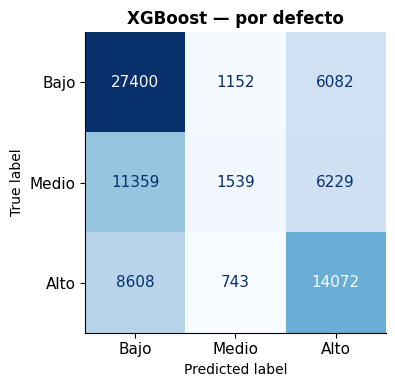

{}


In [64]:
# ── Matriz de confusión — modelo por defecto ──────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
cm_dt = confusion_matrix(y_test, y_pred_xgb)
disp  = ConfusionMatrixDisplay(cm_dt, display_labels=['Bajo','Medio','Alto'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('XGBoost — por defecto', fontweight='bold')
plt.tight_layout()
plt.show()

print(evals_results)

### Early stopping

La solución para dejar de agregar árboles a medida que el error no mejora es utilizar el early stopping, para así tener la mejor cantidad de árboles posible para dicho problema. Para eso separamos una parte del entrenamiento como validación.

In [65]:
from sklearn.metrics import log_loss
from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

xgb_earlstopp = xgb.XGBClassifier(
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss',
    early_stopping_rounds=10
)

xgb_earlstopp.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)

print(f"Árboles usados: {xgb_earlstopp.best_iteration + 1} de 2000")

Árboles usados: 100 de 2000


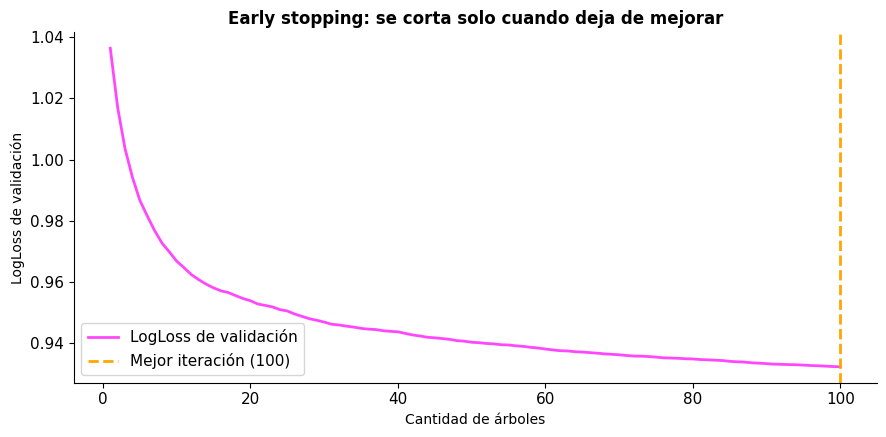

In [66]:
historial = xgb_earlstopp.evals_result()['validation_0']['mlogloss']
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(range(1, len(historial) + 1), historial, color="#ff48fd", lw=2,
        label="LogLoss de validación")
ax.axvline(xgb_earlstopp.best_iteration + 1, color="#ffa600", linestyle="--", lw=2,
           label=f"Mejor iteración ({xgb_earlstopp.best_iteration + 1})")
ax.set_xlabel("Cantidad de árboles")
ax.set_ylabel("LogLoss de validación")
ax.set_title("Early stopping: se corta solo cuando deja de mejorar")
ax.legend()
plt.tight_layout()
plt.show()

### Mejora de Hiperparámetros

Para maximizar el rendimiento del modelo XGBoost, se realizará un ajuste de hiperparámetros utilizando búsqueda aleatoria (`RandomizedSearchCV`). Esto permite explorar el espacio de parámetros de manera eficiente sin necesidad de realizar una búsqueda exhaustiva.

Se ajustarán los parámetros más influyentes:
- **max_depth**: profundidad máxima de cada árbol
- **learning_rate**: tasa de aprendizaje (shrinkage)
- **n_estimators**: número de árboles
- **subsample**: fracción de muestras para entrenar cada árbol
- **colsample_bytree**: fracción de features para cada árbol
- **min_child_weight**: peso mínimo en hojas
- **gamma**: penalidad por complejidad

In [67]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint
import numpy as np

param_dist = {
    'max_depth': randint(3, 10),
    'learning_rate': uniform(0.01, 0.3),
    'n_estimators': randint(100, 500),
    'subsample': uniform(0.5, 0.5),
    'colsample_bytree': uniform(0.5, 0.5),
    'min_child_weight': randint(1, 10),
    'gamma': uniform(0, 5)
}

xgb_base = xgb.XGBClassifier(
    random_state=42,
    n_jobs=-1,
    eval_metric='mlogloss',
    scale_pos_weight=1
)

random_search = RandomizedSearchCV(
    xgb_base,
    param_dist,
    n_iter=20,
    cv=3,  
    scoring='f1_macro',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

print('Iniciando búsqueda de hiperparámetros...')

random_search.fit(X_train, y_train)

print('\n\nBúsqueda completada.')
print(f'Mejor F1 (cross-val): {random_search.best_score_:.4f}')
print(f'\n\nMejores hiperparámetros encontrados:')
for param, value in random_search.best_params_.items():
    print(f'  {param}: {value}')

Iniciando búsqueda de hiperparámetros...
Fitting 3 folds for each of 20 candidates, totalling 60 fits


/Users/maximilianocencic/Documents/maestria/amq/AdM-Grupo8-UCDP-GED/.venv/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [22:45:20] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/maximilianocencic/Documents/maestria/amq/AdM-Grupo8-UCDP-GED/.venv/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [22:45:20] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/maximilianocencic/Documents/maestria/amq/AdM-Grupo8-UCDP-GED/.venv/lib/python3.11/site-packages/xgboost/training.py:200: UserWarning: [22:45:20] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/Users/maximilianocencic/Documents/maestria/amq/AdM-Grupo8-UCDP-GED



Búsqueda completada.
Mejor F1 (cross-val): 0.4777


Mejores hiperparámetros encontrados:
  colsample_bytree: 0.7200762468698007
  gamma: 0.6101911742238941
  learning_rate: 0.15855307303338106
  max_depth: 9
  min_child_weight: 3
  n_estimators: 305
  subsample: 0.6955303037866204


In [68]:
xgb_best = random_search.best_estimator_

y_pred_xgb_best = xgb_best.predict(X_test)
y_pred_xgb_best_train = xgb_best.predict(X_train)

acc_xgb_best = accuracy_score(y_test, y_pred_xgb_best)
f1_xgb_best = f1_score(y_test, y_pred_xgb_best, average='macro', zero_division=0)
acc_xgb_best_train = accuracy_score(y_train, y_pred_xgb_best_train)
f1_xgb_best_train = f1_score(y_train, y_pred_xgb_best_train, average='macro', zero_division=0)

print('=' * 52)
print('  XGBOOST — Hiperparámetros optimizados')
print('=' * 52)
print()
print(f'  {"Conjunto":<12} {"Accuracy":>10} {"Macro F1":>10}')
print(f'  {"-"*34}')
print(f'  {"Train":<12} {acc_xgb_best_train:>10.4f} {f1_xgb_best_train:>10.4f}')
print(f'  {"Test":<12} {acc_xgb_best:>10.4f} {f1_xgb_best:>10.4f}')
print(f'  {"Gap":<12} {acc_xgb_best_train - acc_xgb_best:>+10.4f} {f1_xgb_best_train - f1_xgb_best:>+10.4f}')
print()
print('  Reporte por clase (test):')
print(classification_report(y_test, y_pred_xgb_best,
                             target_names=['Bajo','Medio','Alto'],
                             zero_division=0))

  XGBOOST — Hiperparámetros optimizados

  Conjunto       Accuracy   Macro F1
  ----------------------------------
  Train            0.5913     0.5075
  Test             0.5665     0.4781
  Gap             +0.0248    +0.0294

  Reporte por clase (test):
              precision    recall  f1-score   support

        Bajo       0.59      0.79      0.68     34634
       Medio       0.43      0.12      0.18     19127
        Alto       0.55      0.61      0.58     23423

    accuracy                           0.57     77184
   macro avg       0.52      0.50      0.48     77184
weighted avg       0.54      0.57      0.52     77184



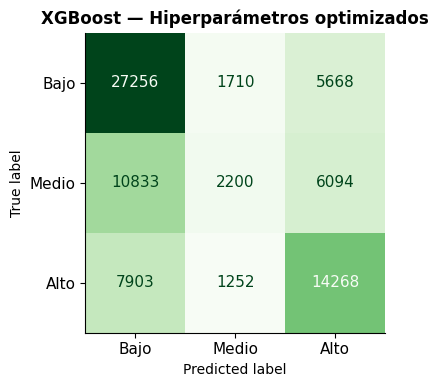

In [69]:

fig, ax = plt.subplots(figsize=(5, 4))
cm_xgb_best = confusion_matrix(y_test, y_pred_xgb_best)
disp = ConfusionMatrixDisplay(cm_xgb_best, display_labels=['Bajo','Medio','Alto'])
disp.plot(ax=ax, cmap='Greens', colorbar=False)
ax.set_title('XGBoost — Hiperparámetros optimizados', fontweight='bold')
plt.tight_layout()
plt.show()

In [70]:
# ── Calcular métricas de train para todos los modelos ────────────────────

# Decision Tree (usando el modelo optimizado)
y_pred_dt_train = best_dt.predict(X_train_sel)
acc_dt_train = accuracy_score(y_train, y_pred_dt_train)
f1_dt_train = f1_score(y_train, y_pred_dt_train, average='macro', zero_division=0)
# Métricas de test (optimizado)
acc_dt = acc_dt_opt
f1_dt = f1_dt_opt

# Random Forest (usando el modelo optimizado)
y_pred_rf_train = best_rf.predict(X_train_sel)
acc_rf_train = accuracy_score(y_train, y_pred_rf_train)
f1_rf_train = f1_score(y_train, y_pred_rf_train, average='macro', zero_division=0)
# Métricas de test (optimizado)
acc_rf = acc_rf_opt
f1_rf = f1_rf_opt

# XGBoost ya tiene las métricas de train/test calculadas en celdas anteriores

print('✅ Métricas de train calculadas para todos los modelos')
print()
print('Resumen rápido:')
print(f'  Decision Tree Train Acc: {acc_dt_train:.4f} | Test Acc: {acc_dt:.4f}')
print(f'  Random Forest Train Acc: {acc_rf_train:.4f} | Test Acc: {acc_rf:.4f}')
print(f'  XGBoost Default Train Acc: {acc_xgb_train:.4f} | Test Acc: {acc_xgb:.4f}')
print(f'  XGBoost Tuned Train Acc: {acc_xgb_best_train:.4f} | Test Acc: {acc_xgb_best:.4f}')

✅ Métricas de train calculadas para todos los modelos

Resumen rápido:
  Decision Tree Train Acc: 0.6011 | Test Acc: 0.5676
  Random Forest Train Acc: 0.6622 | Test Acc: 0.5923
  XGBoost Default Train Acc: 0.5686 | Test Acc: 0.5573
  XGBoost Tuned Train Acc: 0.5913 | Test Acc: 0.5665


## Comparación Final: Todos los Modelos

A continuación se presenta un resumen comparativo del rendimiento de los cuatro modelos entrenados en esta sección: Árbol de Decisión, Random Forest, XGBoost por defecto y XGBoost optimizado.

In [71]:
import pandas as pd

# Crear tabla comparativa
comparison_data = {
    'Modelo': ['Decision Tree (Opt)', 'Random Forest (Opt)', 'XGBoost (Default)', 'XGBoost (Tuned)'],
    'Train Accuracy': [
        acc_dt_train,
        acc_rf_train,
        acc_xgb_train,
        acc_xgb_best_train
    ],
    'Test Accuracy': [
        acc_dt,
        acc_rf,
        acc_xgb,
        acc_xgb_best
    ],
    'Train F1 (macro)': [
        f1_dt_train,
        f1_rf_train,
        f1_xgb_train,
        f1_xgb_best_train
    ],
    'Test F1 (macro)': [
        f1_dt,
        f1_rf,
        f1_xgb,
        f1_xgb_best
    ],
    'Overfitting (Δ Acc)': [
        acc_dt_train - acc_dt,
        acc_rf_train - acc_rf,
        acc_xgb_train - acc_xgb,
        acc_xgb_best_train - acc_xgb_best
    ]
}

df_comparison = pd.DataFrame(comparison_data)

# Formatear para mejor legibilidad
print('\n' + '='*100)
print('COMPARACIÓN FINAL DE MODELOS')
print('='*100 + '\n')
print(df_comparison.to_string(index=False, float_format=lambda x: f'{x:.4f}'))
print('\n' + '='*100)

# Identificar mejor modelo
best_model_idx = df_comparison['Test Accuracy'].idxmax()
best_model_name = df_comparison.loc[best_model_idx, 'Modelo']
best_accuracy = df_comparison.loc[best_model_idx, 'Test Accuracy']

print(f'\n🏆 MEJOR MODELO: {best_model_name} con Accuracy = {best_accuracy:.4f}')
print(f'\nMejora vs Decision Tree: {(best_accuracy - df_comparison.loc[0, "Test Accuracy"])*100:.2f}%')


COMPARACIÓN FINAL DE MODELOS

             Modelo  Train Accuracy  Test Accuracy  Train F1 (macro)  Test F1 (macro)  Overfitting (Δ Acc)
Decision Tree (Opt)          0.6011         0.5676            0.5844           0.5488               0.0334
Random Forest (Opt)          0.6622         0.5923            0.6444           0.5661               0.0699
  XGBoost (Default)          0.5686         0.5573            0.4701           0.4566               0.0114
    XGBoost (Tuned)          0.5913         0.5665            0.5075           0.4781               0.0248


🏆 MEJOR MODELO: Random Forest (Opt) con Accuracy = 0.5923

Mejora vs Decision Tree: 2.47%


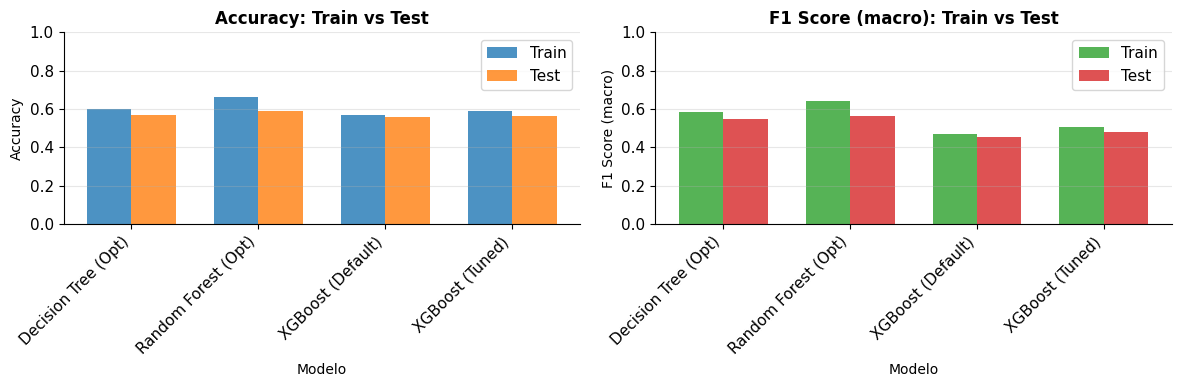

In [72]:
# Visualización de comparación
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy comparison
x_pos = np.arange(len(df_comparison))
width = 0.35

axes[0].bar(x_pos - width/2, df_comparison['Train Accuracy'], width, label='Train', alpha=0.8, color='#1f77b4')
axes[0].bar(x_pos + width/2, df_comparison['Test Accuracy'], width, label='Test', alpha=0.8, color='#ff7f0e')
axes[0].set_xlabel('Modelo')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy: Train vs Test')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(df_comparison['Modelo'], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([0, 1])

# F1 Score comparison
axes[1].bar(x_pos - width/2, df_comparison['Train F1 (macro)'], width, label='Train', alpha=0.8, color='#2ca02c')
axes[1].bar(x_pos + width/2, df_comparison['Test F1 (macro)'], width, label='Test', alpha=0.8, color='#d62728')
axes[1].set_xlabel('Modelo')
axes[1].set_ylabel('F1 Score (macro)')
axes[1].set_title('F1 Score (macro): Train vs Test')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(df_comparison['Modelo'], rotation=45, ha='right')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.show()

---

## Conclusión General

### Resumen de resultados

A lo largo de este trabajo se entrenaron y evaluaron cuatro modelos supervisados para predecir la severidad de eventos de conflicto armado (UCDP GED), clasificada en tres niveles: **Bajo**, **Medio** y **Alto**. La métrica principal de comparación es el **Macro F1**, que penaliza por igual los errores en las tres clases independientemente de su frecuencia.

| Modelo | Train Acc | Test Acc | Train F1 | Test F1 | Gap F1 (Δ) |
|---|---|---|---|---|---|
| **Baseline heurístico** | — | 0.4487 | — | 0.2065 | — |
| **Decision Tree (opt.)** | 0.6011 | 0.5676 | 0.5844 | 0.5488 | 0.0356 |
| **Random Forest (opt.)** | 0.6622 | **0.5923** | 0.6444 | **0.5661** | 0.0783 |
| **XGBoost (default)** | 0.5686 | 0.5573 | 0.4701 | 0.4566 | 0.0135 |
| **XGBoost (opt.)** | 0.5913 | 0.5665 | 0.5075 | 0.4781 | 0.0294 |

### Análisis comparativo

**El Random Forest optimizado es el mejor modelo del trabajo**, con un Test F1 de **0.5661** y Test Accuracy de **0.5923**. Logra el mayor poder predictivo a costa de un gap moderado (ΔF1 = 0.078), que indica cierto sobreajuste controlado por la búsqueda de hiperparámetros (`max_depth=30`, `min_samples_leaf=1`).

**El árbol de decisión optimizado** es el segundo mejor en Macro F1 (0.5488) y el que mejor equilibra capacidad y generalización entre los modelos basados en árboles. Su gap es el más bajo del grupo (ΔF1 = 0.036), resultado de la regularización vía `min_samples_split=200`. Sin embargo, al ser un modelo único, su varianza es mayor y su robustez inferior al ensamble.

**XGBoost presenta un resultado contra-intuitivo**: su versión por defecto obtiene el gap más bajo de todos (ΔF1 = 0.0135), pero también el Macro F1 más bajo (0.4566). Esto no indica que generalice bien, sino que los hiperparámetros por defecto de XGBoost (100 árboles, `max_depth=6`, `learning_rate=0.3`) son demasiado conservadores para un dataset de 308k filas con tres clases. Tras la optimización, el F1 sube a 0.4781, pero no alcanza al Random Forest. Esto probablemente se debe a que la búsqueda aleatoria con solo 20 iteraciones y 3 folds es insuficiente para explorar el espacio de hiperparámetros de XGBoost, que es considerablemente más amplio que el de Random Forest.

**Todos los modelos superan ampliamente el baseline**, que simplemente aplicaba el criterio de la clase mayoritaria, confirmando que los features disponibles contienen información predictiva real sobre la severidad. El salto más importante se da al pasar del baseline al árbol de decisión (+0.34 puntos de Macro F1).

### Comentario sobre el dataset: la clase Medio

En todos los modelos, la clase **Medio** es consistentemente la más difícil de predecir, con F1 que no supera 0.40 en ninguna configuración. Esto tiene una causa estructural, relacionada con los umbrales de discretización (percentiles 33 y 66). Estos generan fronteras muy estrechas entre clases contiguas. Eventos con 2 o 3 bajas pueden caer en Bajo o Medio según pequeñas variaciones, y ningún algoritmo puede resolver esa ambigüedad a partir de los features disponibles. El techo del Macro F1 está en gran medida determinado por esta limitación del target, no del modelo.

### Posibles mejoras

Los resultados obtenidos son una base sólida, pero existe margen de mejora en varias direcciones:

**Mejoras en el target:**
- Revisar los umbrales de discretización. Umbrales basados en cuantiles sobre escala logarítmica de `best` podrían generar clases más separables que los percentiles sobre valores enteros.

**Mejoras en features:**
- Incorporar features de contexto temporal: promedio histórico de bajas del conflicto, tendencia reciente por país, o número de eventos previos del mismo `dyad` en el último año.
- Explorar interacciones entre `type_of_violence` y `country_te`, que el feature importance del RF sugiere como las variables más discriminativas.

**Mejoras en modelado:**
- **XGBoost con búsqueda más exhaustiva:** aumentar a 50–100 iteraciones con 5 folds, e incluir `min_child_weight` y `gamma` como ejes principales de regularización para controlar el overfitting sin underfit.
- **Random Forest con mayor regularización:** fijar `max_depth` entre 8 y 15 con `min_samples_leaf` entre 20 y 100, apuntando a reducir el gap ΔF1 por debajo de 0.04 sin sacrificar Test F1.
- **LightGBM** como alternativa a XGBoost: más eficiente en datasets grandes y con mejores hiperparámetros por defecto para este tipo de problema, potencialmente cerrando la brecha con Random Forest.
- **Calibración de probabilidades** con `CalibratedClassifierCV` sobre el modelo final, para mejorar la calidad de las curvas ROC sin modificar las predicciones de clase.